In [115]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [116]:
%autoreload 2
%aimport sog1_helpers

import pandas as pd
from Bio.Seq import Seq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

#plt.rcParams['text.usetex'] = True

plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

# Phosphosite variants

Analysis plan:
1. Effect of phosphomutants relative to WT?
- Line plot of WT tiles vs phosphomutant tiles
2. Do the newly confirmed phosphosites (T96, T249 and T273) play a role in activity?
3. Do all confirmed PS contribute equally to activity? 
- Use single confirmed A (A1c1):
    - plot WT trace vs scatter of variants
    - And above, plot a bar graph with fold change of each variant 
4. Are there non-confirmed PS that contribute to activity? 
- Do predicted PS contribute to activity?: Full confirmed (A1c1) vs Full confirmed + predicted (A1b)
- Do other residues contribute to activity?: Full confirmed + predicted (A1b) vs maximal phospho mutant (A1a)
5. Is there an ordering when phosphorylation matters?
- Heatmap or scatter plot ??
6. Does the presence/lack of the aromatic ring in the substituent (Ala versus Phe) alter the outcome? 
- Scatter plot of A1a vs A2a
- Scatter plot of A1b vs A2b


In [117]:
activity_col = "Activity_S3_1"

# Helper function to get relevant rows of library
--> Now in sog1_helpers.py

In [118]:
# library = pd.read_excel("../margot_raw/SeqLib_Visit2_2023.xlsx", sheet_name = "Visit2")
# library = library[["ProteinSeq", "Description", "Other"]]
# library["Description"] = library["Description"].astype(str)
# library

In [119]:
# def return_activities(description, pos_regex = r'(\d+)_.*'):
#     library_rows = library[library["Description"].str.contains(description)]
#     library_rows["Start"] = library_rows["Description"].str.extract(pos_regex).astype(int)
#     library_rows["Start"] = 10 * library_rows["Start"] - 9
#     library_rows.loc[library_rows['Start'] ==411, 'Start'] = 410
#     library_rows["mid"] = library_rows["Start"] + 20
#     library_rows["End"] = library_rows["Start"] + 40
#     library_rows["tile"] = library_rows["ProteinSeq"].astype(str).str.strip()
#     library_rows = library_rows.drop(columns = {"ProteinSeq"})
    
#     #activities = pd.read_csv("../data/Sog1_library2_activities_with_reads.csv")
#     activities = pd.read_csv("../data/Sog1_library2_activities_with_reads_ECspike.csv")
#     #activities = pd.read_csv("../data/Sog1_library2_activities_with_reads_EC.csv")
#     activities = activities.rename(columns = {"AAseq" : "tile"})
#     activities["tile"] = activities["tile"].astype(str).str.strip()
      
#     return pd.merge(library_rows, activities[["tile", "Activity_S3_1", "Activity_S3_2", "lib2_avg"]], on = "tile", how = "left")

# 1. Effect of phosphomutants relative to WT?

In [124]:
# Full confirmed phosphomutant tiles
PSv_conf2fA_STYA = sog1_helpers.return_activities("PSv_conf2fA_STYA")
PSv_conf2fA_STYA.head(3)

,Start,End,Description,Other,mid,tile,Activity_S3_1,Activity_S3_2,lib2_avg,unweighted_std,weighted_std,activ_err_start,activ_err_end
0,61,100,7_PSv_conf2fA_STYA,NaN,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,602.055974,567.661610,584.858792,773.857346,419.896382,182.159592,1021.952356
1,71,110,8_PSv_conf2fA_STYA,NaN,91,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,2092.472748,2127.003654,2109.738201,1215.818623,905.227739,1187.245009,2997.700487
2,81,120,9_PSv_conf2fA_STYA,NaN,101,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,1501.606009,1112.678850,1307.142429,2599.241727,1666.743191,-165.137182,3168.349200


In [125]:
# WT tiles
BasicArTh = sog1_helpers.return_activities("BasicArTh", pos_regex = r'\.(\d+)')
BasicArTh.head(3)

,Start,End,Description,Other,mid,tile,Activity_S3_1,Activity_S3_2,lib2_avg,unweighted_std,weighted_std,activ_err_start,activ_err_end
0,1,40,BasicArTh.1,Q6NQK2,21,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,346.212032,1244.615820,795.413926,1361.077597,194.588164,151.623867,540.800196
1,11,50,BasicArTh.2,Q6NQK2,31,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,497.045903,3954.541874,2225.793889,1468.340091,463.658678,33.387226,960.704581
2,21,60,BasicArTh.3,Q6NQK2,41,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,744.162543,1013.665108,878.913825,825.990975,335.021566,409.140977,1079.184108


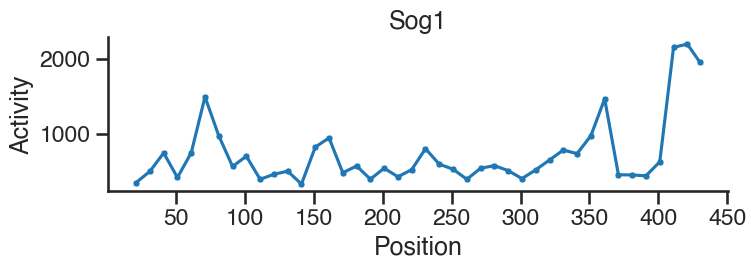

In [126]:
sns.set_context('talk')
# Plotting the WT tiles
plt.figure(figsize = (8, 2))
sns.lineplot(data = BasicArTh, x = "mid", y = activity_col)
sns.scatterplot(data = BasicArTh, x = "mid", y = activity_col, s = 25)

plt.title("Sog1")
plt.ylabel("Activity")
plt.xlabel("Position")
#plt.legend(bbox_to_anchor = (1,1))
sns.despine()

In [127]:
# Add error bars
BasicArTh["activ_err_start"] = BasicArTh["Activity_S3_1"] - BasicArTh["weighted_std"]
BasicArTh["activ_err_end"] = BasicArTh["Activity_S3_1"] + BasicArTh["weighted_std"]
BasicArTh.head(5)

,Start,End,Description,Other,mid,tile,Activity_S3_1,Activity_S3_2,lib2_avg,unweighted_std,weighted_std,activ_err_start,activ_err_end
0,1,40,BasicArTh.1,Q6NQK2,21,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,346.212032,1244.615820,795.413926,1361.077597,194.588164,151.623867,540.800196
1,11,50,BasicArTh.2,Q6NQK2,31,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,497.045903,3954.541874,2225.793889,1468.340091,463.658678,33.387226,960.704581
2,21,60,BasicArTh.3,Q6NQK2,41,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,744.162543,1013.665108,878.913825,825.990975,335.021566,409.140977,1079.184108
3,31,70,BasicArTh.4,Q6NQK2,51,WKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPE,415.149864,3782.725600,2098.937732,959.815081,161.803988,253.345876,576.953853
4,41,80,BasicArTh.5,Q6NQK2,61,KCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSG,746.252478,933.900949,840.076714,886.461169,257.157220,489.095258,1003.409697


(0.0, 3522.6573809913843)

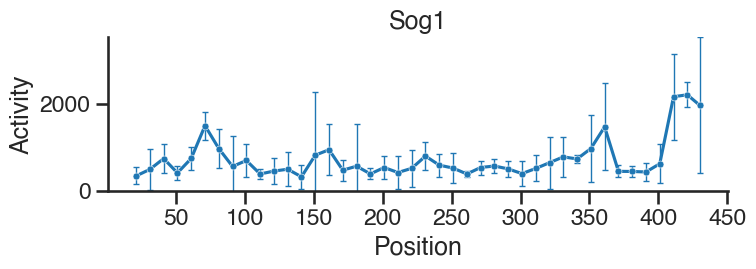

In [128]:
sns.set_context('talk')
# Plotting the WT tiles
plt.figure(figsize = (8, 2))
sns.lineplot(data = BasicArTh, x = "mid", y = activity_col)
sns.scatterplot(data = BasicArTh, x = "mid", y = activity_col, s = 25, zorder =2)

plt.title("Sog1")
plt.ylabel("Activity")
plt.xlabel("Position")
#plt.legend(bbox_to_anchor = (1,1))
sns.despine()

plt.errorbar(BasicArTh["mid"], 
             BasicArTh["Activity_S3_1"], 
             yerr=[BasicArTh["weighted_std"], BasicArTh["weighted_std"]], 
             fmt='none', 
             ecolor=sns.color_palette('tab10')[0], 
             elinewidth=1, 
             capsize=2, 
             zorder = 0)
plt.ylim(0, max(BasicArTh["activ_err_end"]))


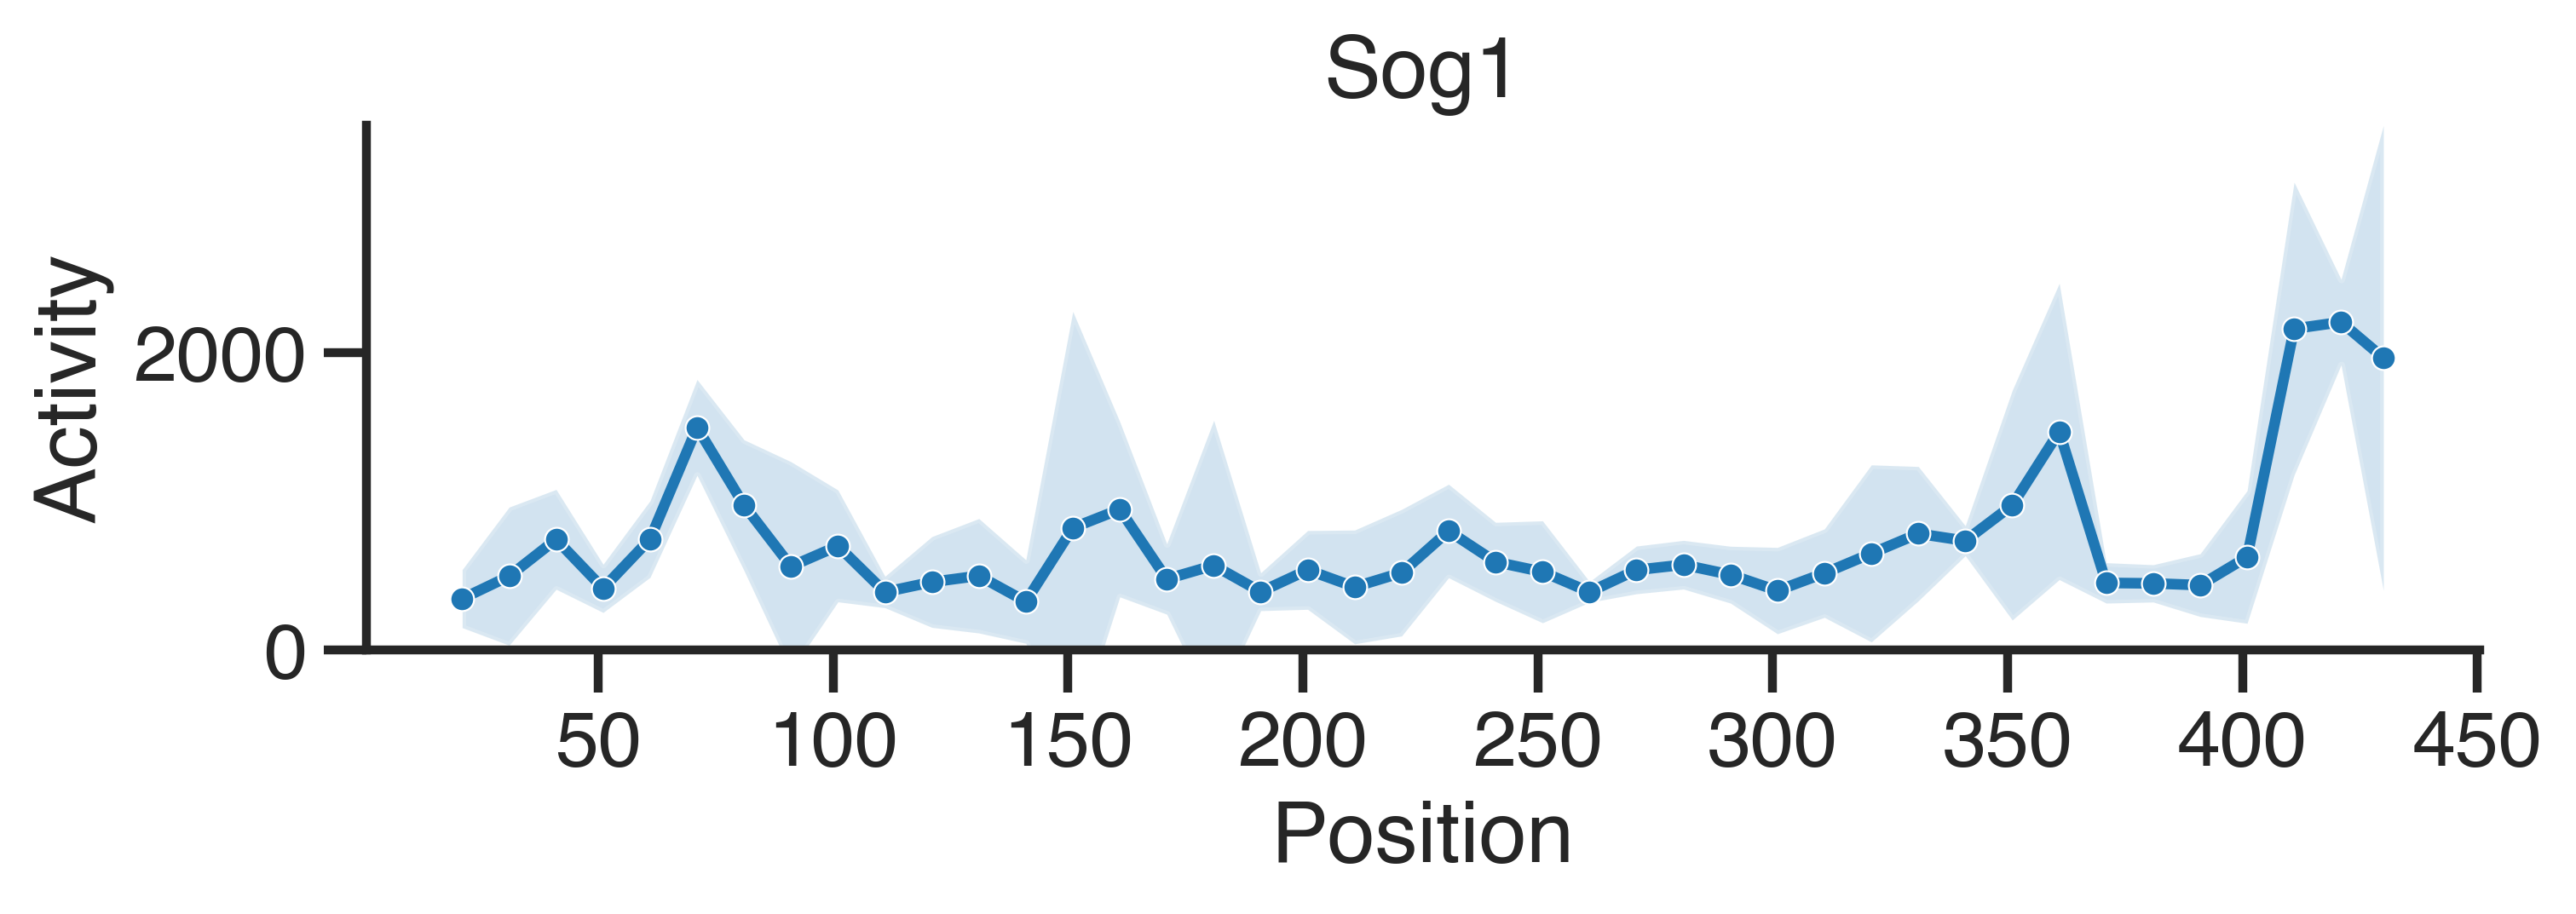

In [209]:
sns.set_context('talk')
# Plotting the WT tiles
plt.figure(figsize = (8, 2), dpi = 400)
ax = sns.lineplot(data = BasicArTh, x = "mid", y = activity_col)
ax.fill_between(BasicArTh["mid"], BasicArTh["activ_err_start"],  BasicArTh["activ_err_end"], alpha=0.2)

sns.scatterplot(data = BasicArTh, x = "mid", y = activity_col, s = 25, zorder =2, color = sns.color_palette('tab10')[0])


plt.ylim(0, max(BasicArTh["activ_err_end"]))
plt.title("Sog1")
plt.ylabel("Activity")
plt.xlabel("Position")
#plt.legend(bbox_to_anchor = (1,1))
sns.despine()


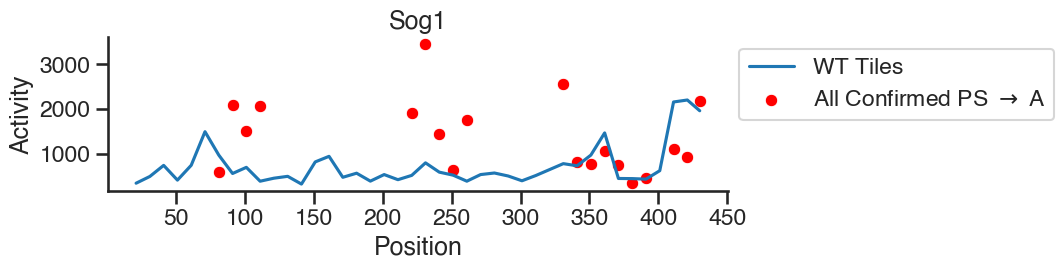

In [130]:
plt.figure(figsize = (8, 2))
sns.lineplot(data = BasicArTh, x = "mid", y = activity_col, label = "WT Tiles")
sns.scatterplot(data = PSv_conf2fA_STYA, x = "mid", y = activity_col, color = "red", label = "All Confirmed PS $\\rightarrow$ A")
plt.title("Sog1")
plt.ylabel("Activity")
plt.xlabel("Position")
plt.legend(bbox_to_anchor = (1,1))
sns.despine()

(0.0, 5190.730808074302)

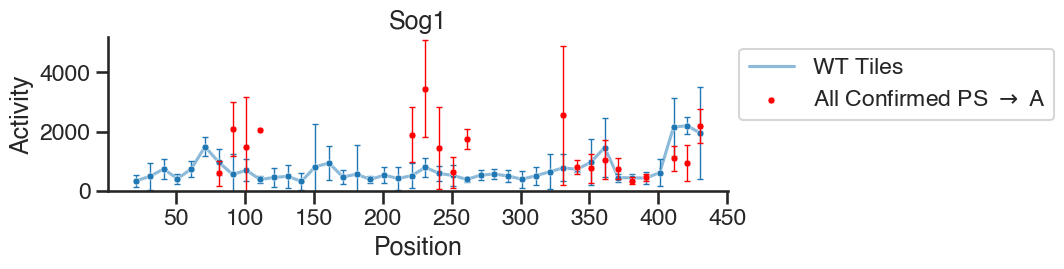

In [131]:
plt.figure(figsize = (8, 2))
sns.lineplot(data = BasicArTh, x = "mid", y = activity_col, label = "WT Tiles", alpha = 0.5)
sns.scatterplot(data = BasicArTh, x = "mid", y = activity_col, s = 25, zorder =2, color = sns.color_palette('tab10')[0])
plt.errorbar(BasicArTh["mid"], 
             BasicArTh["Activity_S3_1"], 
             yerr=[BasicArTh["weighted_std"], BasicArTh["weighted_std"]], 
             fmt='none', 
             ecolor=sns.color_palette('tab10')[0], 
             elinewidth=1, 
             capsize=2, 
             zorder = 0)

sns.scatterplot(data = PSv_conf2fA_STYA, x = "mid", y = activity_col, color = "red", label = "All Confirmed PS $\\rightarrow$ A", s = 25, zorder = 2)
plt.errorbar(PSv_conf2fA_STYA["mid"], 
             PSv_conf2fA_STYA["Activity_S3_1"], 
             yerr=[PSv_conf2fA_STYA["weighted_std"], PSv_conf2fA_STYA["weighted_std"]], 
             fmt='none', 
             ecolor='red', 
             elinewidth=1, 
             capsize=2, 
             zorder = 2)

plt.title("Sog1")
plt.ylabel("Activity")
plt.xlabel("Position")
plt.legend(bbox_to_anchor = (1,1))
sns.despine()

plt.ylim(0, 100 + max([max(df["activ_err_end"]) for df in [BasicArTh, PSv_conf2fA_STYA]]))


In [132]:
# confirmed -> D
PSv_conf2fD = sog1_helpers.return_activities("PSv_conf2fD")
PSv_conf2fD = PSv_conf2fD[~PSv_conf2fD["Description"].str.contains("DD")]
PSv_conf2fD.head(3)

,Start,End,Description,Other,mid,tile,Activity_S3_1,Activity_S3_2,lib2_avg,unweighted_std,weighted_std,activ_err_start,activ_err_end
0,61,100,7_PSv_conf2fD,/,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPDVNQD,569.301009,525.559638,547.430324,1014.447125,584.160046,-14.859037,1153.461055
1,71,110,8_PSv_conf2fD,/,91,IIWHLLAKSGLSGLSSHPFIDEFIPDVNQDDGICYTHPKN,972.107949,964.886411,968.497180,NaN,0.000000,972.107949,972.107949
2,81,120,9_PSv_conf2fD,/,101,LSGLSSHPFIDEFIPDVNQDDGICYTHPKNLPGVKSDGTV,3352.134612,3734.635082,3543.384847,1143.363847,643.715527,2708.419085,3995.850139


(0.0, 6276.4917143928515)

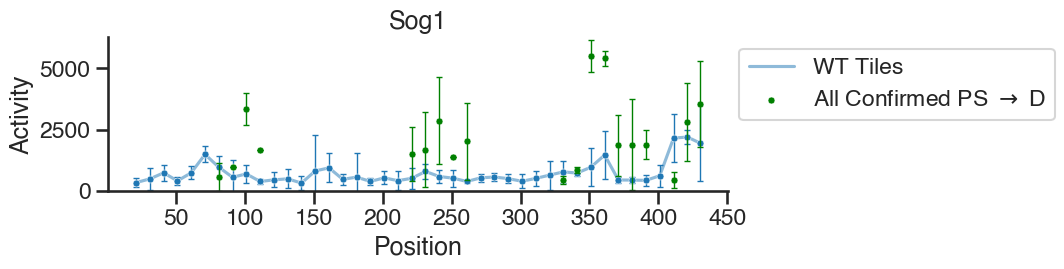

In [134]:
plt.figure(figsize = (8, 2))
sns.lineplot(data = BasicArTh, x = "mid", y = activity_col, label = "WT Tiles", alpha = 0.5)
sns.scatterplot(data = BasicArTh, x = "mid", y = activity_col, s = 25, zorder =2, color = sns.color_palette('tab10')[0])
plt.errorbar(BasicArTh["mid"], 
             BasicArTh["Activity_S3_1"], 
             yerr=[BasicArTh["weighted_std"], BasicArTh["weighted_std"]], 
             fmt='none', 
             ecolor=sns.color_palette('tab10')[0], 
             elinewidth=1, 
             capsize=2, 
             zorder = 0)

# sns.scatterplot(data = PSv_conf2fA_STYA, x = "mid", y = activity_col, color = "red", label = "All Confirmed PS $\\rightarrow$ A", s = 25, zorder = 2)
# plt.errorbar(PSv_conf2fA_STYA["mid"], 
#              PSv_conf2fA_STYA["Activity_S3_1"], 
#              yerr=[PSv_conf2fA_STYA["weighted_std"], PSv_conf2fA_STYA["weighted_std"]], 
#              fmt='none', 
#              ecolor='red', 
#              elinewidth=1, 
#              capsize=2, 
#              zorder = 2)

sns.scatterplot(data = PSv_conf2fD, x = "mid", y = activity_col, color = "green", label = "All Confirmed PS $\\rightarrow$ D", s = 25, zorder = 2)
plt.errorbar(PSv_conf2fD["mid"], 
             PSv_conf2fD["Activity_S3_1"], 
             yerr=[PSv_conf2fD["weighted_std"], PSv_conf2fD["weighted_std"]], 
             fmt='none', 
             ecolor='green', 
             elinewidth=1, 
             capsize=2, 
             zorder = 2)

plt.title("Sog1")
plt.ylabel("Activity")
plt.xlabel("Position")
plt.legend(bbox_to_anchor = (1,1))
sns.despine()

plt.ylim(0, 100 + max([max(df["activ_err_end"]) for df in [BasicArTh, PSv_conf2fA_STYA, PSv_conf2fD]]))


(0.0, 6276.4917143928515)

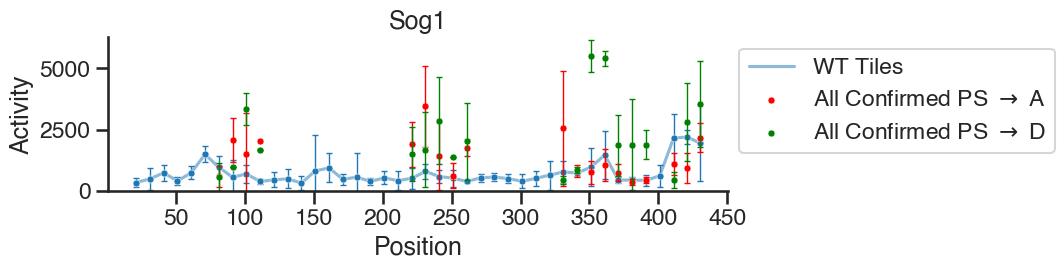

In [135]:
plt.figure(figsize = (8, 2))
sns.lineplot(data = BasicArTh, x = "mid", y = activity_col, label = "WT Tiles", alpha = 0.5)
sns.scatterplot(data = BasicArTh, x = "mid", y = activity_col, s = 25, zorder =2, color = sns.color_palette('tab10')[0])
plt.errorbar(BasicArTh["mid"], 
             BasicArTh["Activity_S3_1"], 
             yerr=[BasicArTh["weighted_std"], BasicArTh["weighted_std"]], 
             fmt='none', 
             ecolor=sns.color_palette('tab10')[0], 
             elinewidth=1, 
             capsize=2, 
             zorder = 0)

sns.scatterplot(data = PSv_conf2fA_STYA, x = "mid", y = activity_col, color = "red", label = "All Confirmed PS $\\rightarrow$ A", s = 25, zorder = 2)
plt.errorbar(PSv_conf2fA_STYA["mid"], 
             PSv_conf2fA_STYA["Activity_S3_1"], 
             yerr=[PSv_conf2fA_STYA["weighted_std"], PSv_conf2fA_STYA["weighted_std"]], 
             fmt='none', 
             ecolor='red', 
             elinewidth=1, 
             capsize=2, 
             zorder = 2)

sns.scatterplot(data = PSv_conf2fD, x = "mid", y = activity_col, color = "green", label = "All Confirmed PS $\\rightarrow$ D", s = 25, zorder = 2)
plt.errorbar(PSv_conf2fD["mid"], 
             PSv_conf2fD["Activity_S3_1"], 
             yerr=[PSv_conf2fD["weighted_std"], PSv_conf2fD["weighted_std"]], 
             fmt='none', 
             ecolor='green', 
             elinewidth=1, 
             capsize=2, 
             zorder = 2)

plt.title("Sog1")
plt.ylabel("Activity")
plt.xlabel("Position")
plt.legend(bbox_to_anchor = (1,1))
sns.despine()

plt.ylim(0, 100 + max([max(df["activ_err_end"]) for df in [BasicArTh, PSv_conf2fA_STYA, PSv_conf2fD]]))


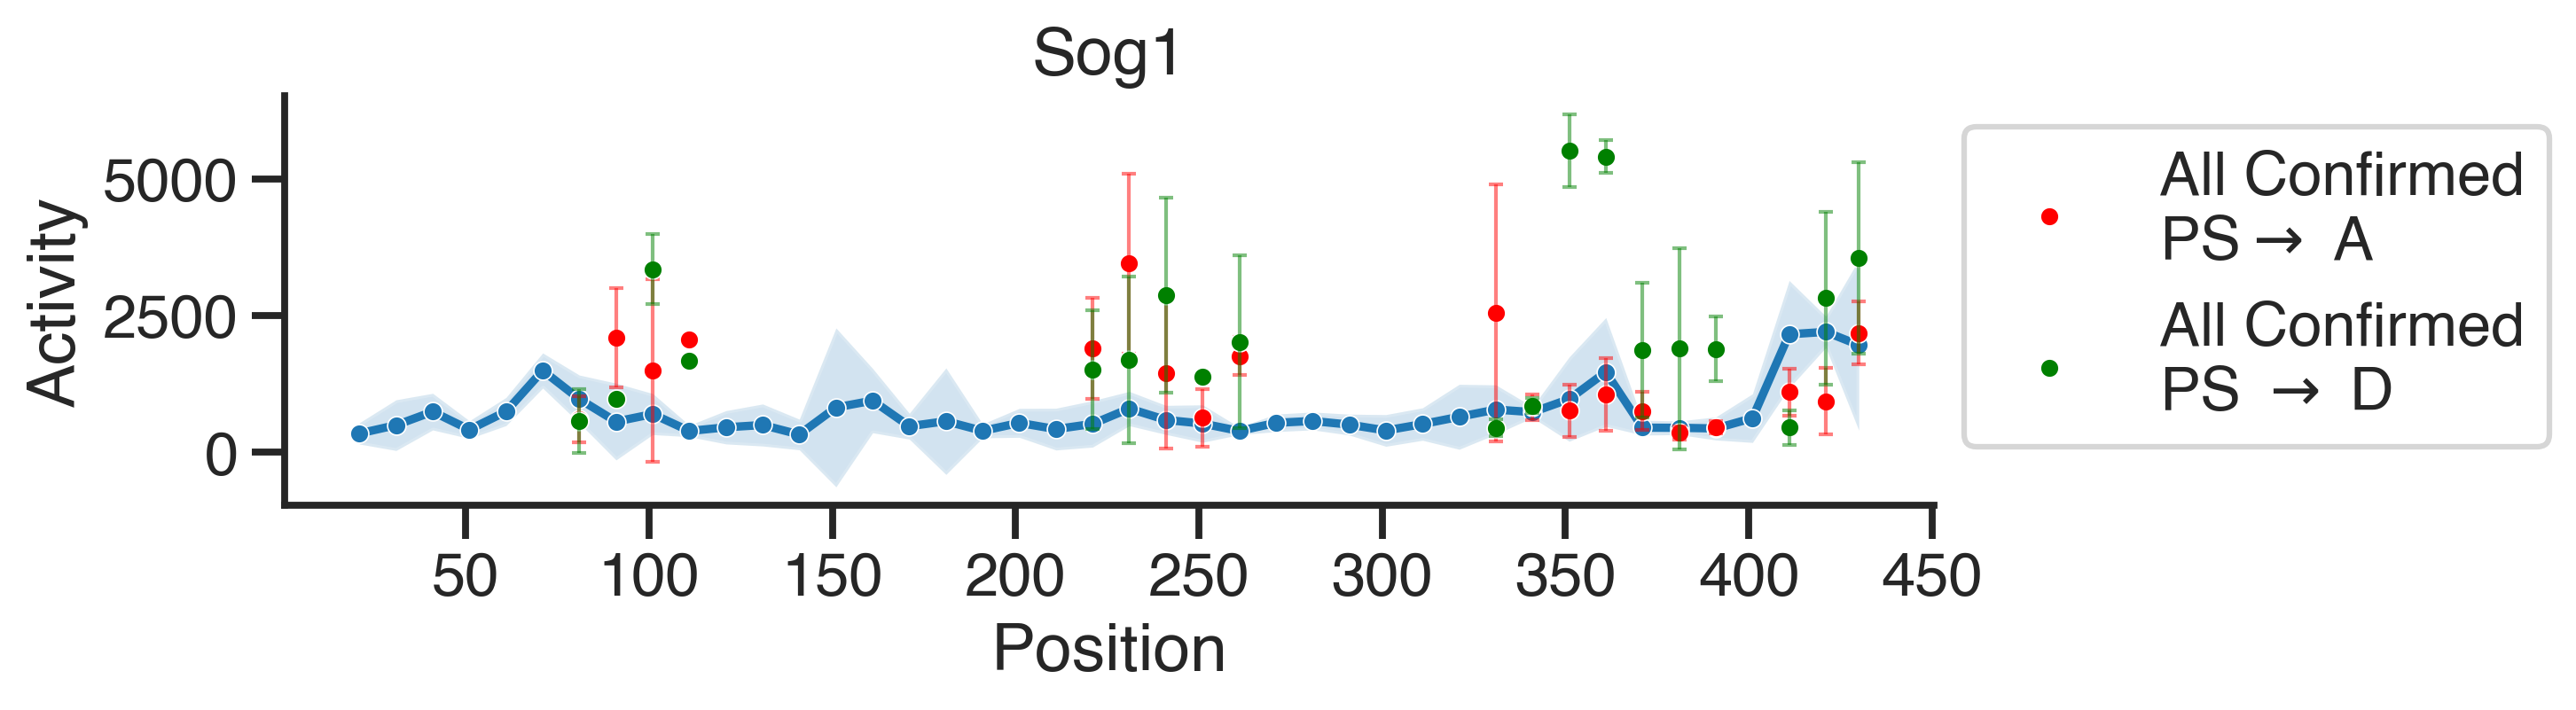

In [153]:
sns.set_context('talk')
# Plotting the WT tiles
plt.figure(figsize = (8, 2), dpi = 300)
ax = sns.lineplot(data = BasicArTh, x = "mid", y = activity_col)
ax.fill_between(BasicArTh["mid"], BasicArTh["activ_err_start"],  BasicArTh["activ_err_end"], alpha=0.2)
sns.scatterplot(data = BasicArTh, x = "mid", y = activity_col, s = 25, zorder =2, color = sns.color_palette('tab10')[0])

# Phosphomut
sns.scatterplot(data = PSv_conf2fA_STYA, x = "mid", y = activity_col, color = "red", label = "All Confirmed\nPS$\\rightarrow$ A", s = 25, zorder = 2)
plt.errorbar(PSv_conf2fA_STYA["mid"], 
             PSv_conf2fA_STYA["Activity_S3_1"], 
             yerr=[PSv_conf2fA_STYA["weighted_std"], PSv_conf2fA_STYA["weighted_std"]], 
             fmt='none', 
             ecolor='red', 
             elinewidth=1, 
             capsize=2, 
             zorder = 2, alpha = 0.5)

sns.scatterplot(data = PSv_conf2fD, x = "mid", y = activity_col, color = "green", label = "All Confirmed\nPS $\\rightarrow$ D", s = 25, zorder = 2)
plt.errorbar(PSv_conf2fD["mid"], 
             PSv_conf2fD["Activity_S3_1"], 
             yerr=[PSv_conf2fD["weighted_std"], PSv_conf2fD["weighted_std"]], 
             fmt='none', 
             ecolor='green', 
             elinewidth=1, 
             capsize=2, 
             zorder = 2, alpha = 0.5)


#plt.ylim(0, max(BasicArTh["activ_err_end"]))
plt.title("Sog1")
plt.ylabel("Activity")
plt.xlabel("Position")
plt.legend(bbox_to_anchor = (1,1))
sns.despine()


In [169]:
PSv_conf2fA_STYA_vs_basic = sog1_helpers.add_var_positions(PSv_conf2fA_STYA, BasicArTh, activity_col)
PSv_conf2fA_STYA_vs_basic

,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,unweighted_std_var,...,Activity_S3_2_wt,lib2_avg_wt,unweighted_std_wt,weighted_std_wt,activ_err_start_wt,activ_err_end_wt,var,activ_diff,activ_fold_change,signif_diff
0,61,100,7_PSv_conf2fA_STYA,NaN,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,602.055974,567.661610,584.858792,773.857346,...,1517.695164,1245.706526,555.827682,439.055694,534.662195,1412.773583,96,-371.661915,0.618306,False
1,71,110,8_PSv_conf2fA_STYA,NaN,91,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,2092.472748,2127.003654,2109.738201,1215.818623,...,369.638636,466.350758,1913.448529,702.321334,-139.258453,1265.384214,96,1529.409868,3.716233,False
2,81,120,9_PSv_conf2fA_STYA,NaN,101,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,1501.606009,1112.678850,1307.142429,2599.241727,...,1403.352788,1051.731838,1325.703495,375.390470,324.720418,1075.501358,96,801.495121,2.144812,False
3,91,130,10_PSv_conf2fA_STYA,NaN,111,DEFIPAVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,2060.557652,1159.883146,1610.220399,NaN,...,1577.686428,984.194231,816.038487,105.284362,285.417672,495.986395,96,1669.855618,5.273988,True
4,201,240,21_PSv_conf2fA_STYA,NaN,221,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVAPTA,1902.742141,2002.619268,1952.680704,1060.765917,...,412.457887,466.499666,1196.977215,424.880030,95.661415,945.421475,237,1382.200696,3.655313,True
5,211,250,22_PSv_conf2fA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVAPTADPVAPKLAAP,3450.490926,3241.749707,3346.120317,1817.063935,...,929.825007,865.083934,973.653282,313.691933,486.650926,1114.034793,237,2650.148066,4.311266,True
6,221,260,23_PSv_conf2fA_STYA,NaN,241,GDKAEQEVSEDIFAAVAPTADPVAPKLAAPEPRNAVRICS,1441.174262,942.209124,1191.691693,1450.332756,...,2265.337229,1429.122488,1718.395787,265.470468,327.437280,858.378215,237,848.266514,2.430689,False
7,231,270,24_PSv_conf2fA_STYA,NaN,251,DIFAAVAPTADPVAPKLAAPEPRNAVRICSDSHIASDYVT,631.170701,749.661133,690.415917,1049.620478,...,573.950031,550.116631,728.245702,342.155127,184.128103,868.438357,237,104.887471,1.199299,False
8,241,280,25_PSv_conf2fA_STYA,NaN,261,DPVAPKLAAPEPRNAVRICSDSHIASDYVTPSDYVSAHEV,1761.327836,1233.415453,1497.371644,509.837822,...,1193.093797,792.153885,943.645257,69.289547,321.924425,460.503520,244,1370.113864,4.502211,True
9,311,350,32_PSv_conf2fA_STYA,NaN,331,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGA,2554.497314,NaN,2554.497314,1422.262945,...,1281.496172,1031.998854,1147.166716,450.818014,331.683523,1233.319551,350,1771.995777,3.264527,False


In [170]:
PSv_conf2fD_vs_basic = sog1_helpers.add_var_positions(PSv_conf2fD, BasicArTh, activity_col)
PSv_conf2fD_vs_basic

,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,unweighted_std_var,...,Activity_S3_2_wt,lib2_avg_wt,unweighted_std_wt,weighted_std_wt,activ_err_start_wt,activ_err_end_wt,var,activ_diff,activ_fold_change,signif_diff
0,61,100,7_PSv_conf2fD,/,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPDVNQD,569.301009,525.559638,547.430324,1014.447125,...,1517.695164,1245.706526,555.827682,439.055694,534.662195,1412.773583,96,-404.416880,0.584667,False
1,71,110,8_PSv_conf2fD,/,91,IIWHLLAKSGLSGLSSHPFIDEFIPDVNQDDGICYTHPKN,972.107949,964.886411,968.497180,NaN,...,369.638636,466.350758,1913.448529,702.321334,-139.258453,1265.384214,96,409.045069,1.726464,True
2,81,120,9_PSv_conf2fD,/,101,LSGLSSHPFIDEFIPDVNQDDGICYTHPKNLPGVKSDGTV,3352.134612,3734.635082,3543.384847,1143.363847,...,1403.352788,1051.731838,1325.703495,375.390470,324.720418,1075.501358,96,2652.023724,4.788005,True
3,91,130,10_PSv_conf2fD,/,111,DEFIPDVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,1677.825445,1028.150576,1352.988011,NaN,...,1577.686428,984.194231,816.038487,105.284362,285.417672,495.986395,96,1287.123412,4.294386,True
4,201,240,21_PSv_conf2fD,/,221,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVDPTA,1513.556696,788.330165,1150.943431,1354.110119,...,412.457887,466.499666,1196.977215,424.880030,95.661415,945.421475,237,993.015251,2.907658,False
5,211,250,22_PSv_conf2fD,/,231,QQPQQLVVKRGDKAEQEVSEDIFAAVDPTADPVDPKLADP,1690.029515,1244.981802,1467.505658,2029.617818,...,929.825007,865.083934,973.653282,313.691933,486.650926,1114.034793,237,889.686655,2.111632,False
6,221,260,23_PSv_conf2fD,/,241,GDKAEQEVSEDIFAAVDPTADPVDPKLADPEPRNAVRICS,2875.726493,2570.852747,2723.289620,1894.404733,...,2265.337229,1429.122488,1718.395787,265.470468,327.437280,858.378215,237,2282.818746,4.850209,True
7,231,270,24_PSv_conf2fD,/,251,DIFAAVDPTADPVDPKLADPEPRNAVRICSDSHIASDYVT,1377.244427,1219.135527,1298.189977,NaN,...,573.950031,550.116631,728.245702,342.155127,184.128103,868.438357,237,850.961197,2.616926,True
8,241,280,25_PSv_conf2fD,/,261,DPVDPKLADPEPRNAVRICSDSHIASDYVTPSDYVSAHEV,2022.516091,1347.526513,1685.021302,2120.614141,...,1193.093797,792.153885,943.645257,69.289547,321.924425,460.503520,244,1631.302119,5.169846,False
9,311,350,32_PSv_conf2fD,/,331,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGD,450.948193,NaN,450.948193,1304.902502,...,1281.496172,1031.998854,1147.166716,450.818014,331.683523,1233.319551,350,-331.553344,0.576290,False


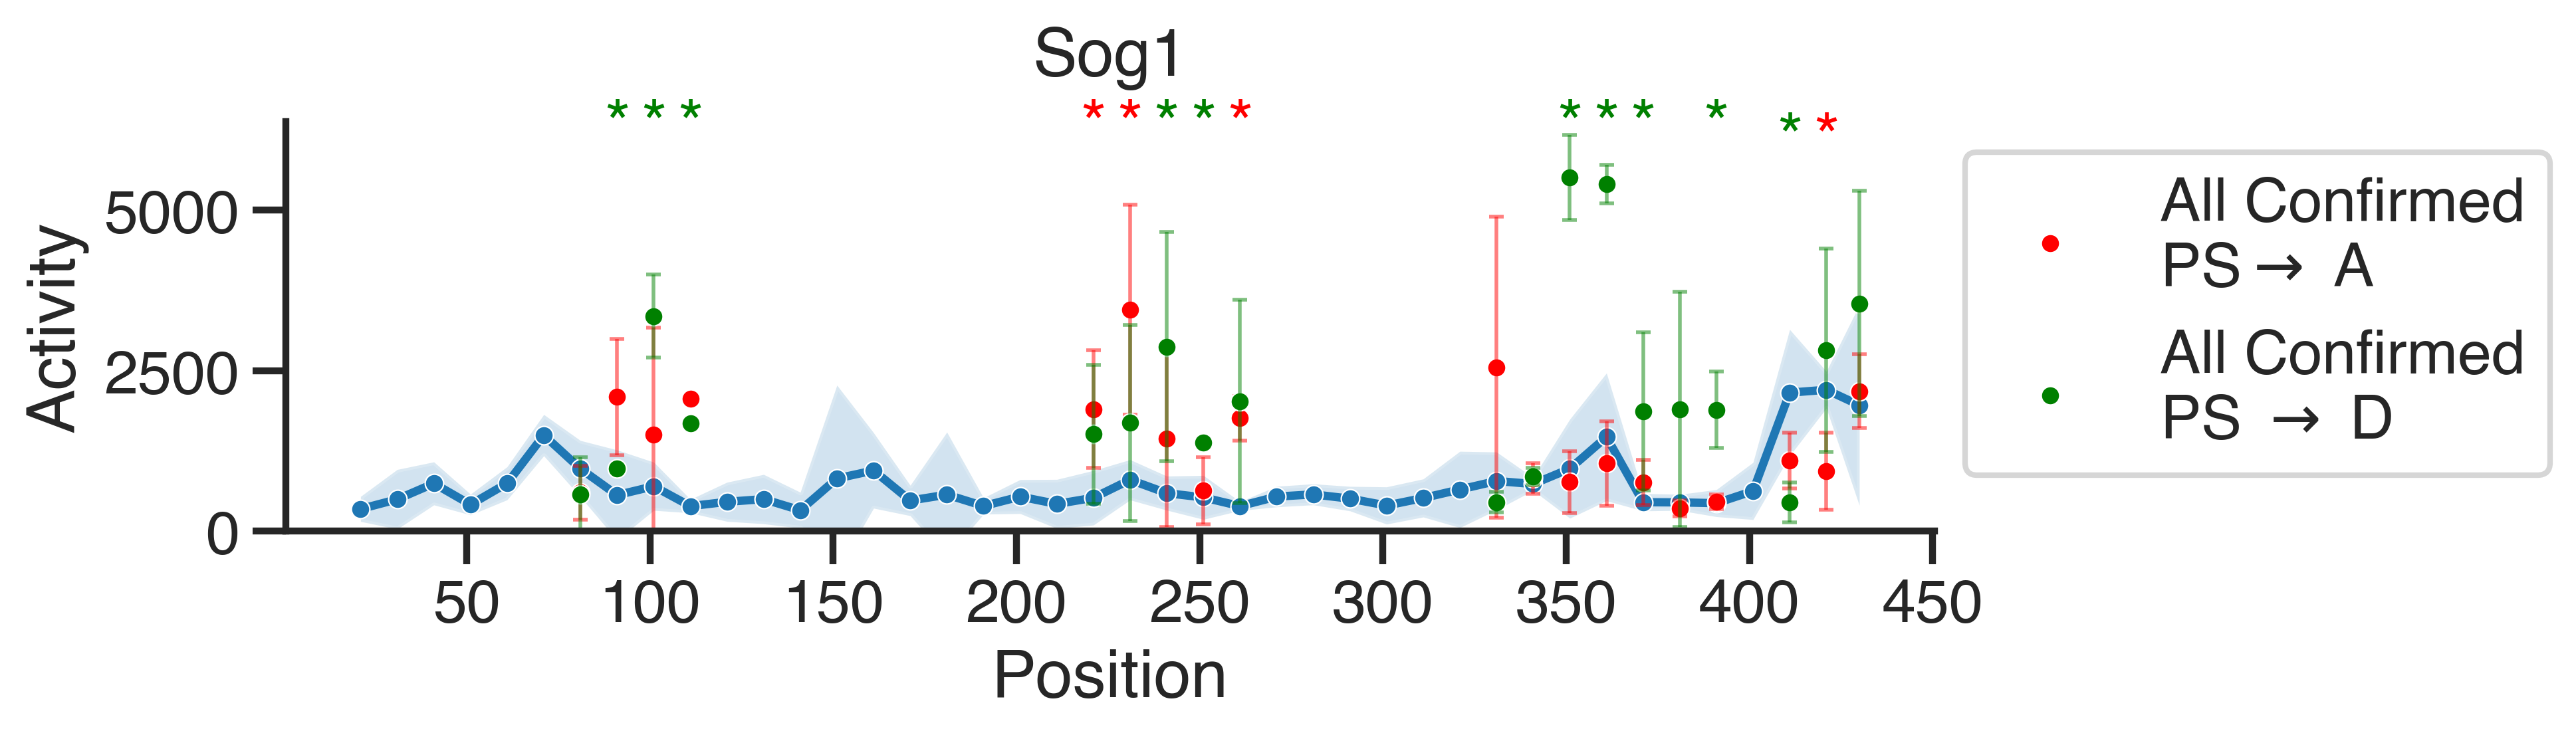

In [214]:
sns.set_context('talk')
# Plotting the WT tiles
plt.figure(figsize = (8, 2), dpi = 400)
ax = sns.lineplot(data = BasicArTh, x = "mid", y = activity_col)
ax.fill_between(BasicArTh["mid"], BasicArTh["activ_err_start"],  BasicArTh["activ_err_end"], alpha=0.2)
sns.scatterplot(data = BasicArTh, x = "mid", y = activity_col, s = 25, zorder =2, color = sns.color_palette('tab10')[0])

## Phosphomut
sns.scatterplot(data = PSv_conf2fA_STYA, x = "mid", y = activity_col, color = "red", label = "All Confirmed\nPS$\\rightarrow$ A", s = 25, zorder = 2)
plt.errorbar(PSv_conf2fA_STYA["mid"], 
             PSv_conf2fA_STYA["Activity_S3_1"], 
             yerr=[PSv_conf2fA_STYA["weighted_std"], PSv_conf2fA_STYA["weighted_std"]], 
             fmt='none', 
             ecolor='red', 
             elinewidth=1, 
             capsize=2, 
             zorder = 2, alpha = 0.5)

# Adding significance
sig_rows = PSv_conf2fA_STYA_vs_basic[PSv_conf2fA_STYA_vs_basic["signif_diff"]]
sig_rows = sig_rows.dropna(subset = ["weighted_std_wt", "weighted_std_var"])
for i in sig_rows.index:
    row = sig_rows.loc[i]
    if row["Activity_S3_1_var"] > row["Activity_S3_1_wt"]:
        plt.text(s = "*", x = row['mid'], y = 6000, ha = 'center', color = 'red')
    else:
        plt.text(s = "*", x = row['mid'], y = 5800, ha = 'center', color = 'red')

## Phosphomim
sns.scatterplot(data = PSv_conf2fD, x = "mid", y = activity_col, color = "green", label = "All Confirmed\nPS $\\rightarrow$ D", s = 25, zorder = 2)
plt.errorbar(PSv_conf2fD["mid"], 
             PSv_conf2fD["Activity_S3_1"], 
             yerr=[PSv_conf2fD["weighted_std"], PSv_conf2fD["weighted_std"]], 
             fmt='none', 
             ecolor='green', 
             elinewidth=1, 
             capsize=2, 
             zorder = 2, alpha = 0.5)

# Adding significance
sig_rows = PSv_conf2fD_vs_basic[PSv_conf2fD_vs_basic["signif_diff"]]
sig_rows = sig_rows.dropna(subset = ["weighted_std_wt", "weighted_std_var"])
for i in sig_rows.index:
    row = sig_rows.loc[i]
    if row["Activity_S3_1_var"] > row["Activity_S3_1_wt"]:
        plt.text(s = "*", x = row['mid'], y = 6000, ha = 'center', color = 'green')
    else:
        plt.text(s = "*", x = row['mid'], y = 5800, ha = 'center', color = 'green')

#plt.ylim(0, max(BasicArTh["activ_err_end"]))
plt.title("Sog1", y = 1.06)
plt.ylabel("Activity")
plt.xlabel("Position")
plt.legend(bbox_to_anchor = (1,1))

plt.ylim(0, 200 + max([max(df["activ_err_end"]) for df in [BasicArTh, PSv_conf2fA_STYA, PSv_conf2fD]]))

sns.despine()


In [210]:
sig_rows

,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,unweighted_std_var,...,Activity_S3_2_wt,lib2_avg_wt,unweighted_std_wt,weighted_std_wt,activ_err_start_wt,activ_err_end_wt,var,activ_diff,activ_fold_change,signif_diff
1,71,110,8_PSv_conf2fD,/,91,IIWHLLAKSGLSGLSSHPFIDEFIPDVNQDDGICYTHPKN,972.107949,964.886411,968.497180,NaN,...,369.638636,466.350758,1913.448529,702.321334,-139.258453,1265.384214,96,409.045069,1.726464,True
2,81,120,9_PSv_conf2fD,/,101,LSGLSSHPFIDEFIPDVNQDDGICYTHPKNLPGVKSDGTV,3352.134612,3734.635082,3543.384847,1143.363847,...,1403.352788,1051.731838,1325.703495,375.390470,324.720418,1075.501358,96,2652.023724,4.788005,True
3,91,130,10_PSv_conf2fD,/,111,DEFIPDVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,1677.825445,1028.150576,1352.988011,NaN,...,1577.686428,984.194231,816.038487,105.284362,285.417672,495.986395,96,1287.123412,4.294386,True
6,221,260,23_PSv_conf2fD,/,241,GDKAEQEVSEDIFAAVDPTADPVDPKLADPEPRNAVRICS,2875.726493,2570.852747,2723.289620,1894.404733,...,2265.337229,1429.122488,1718.395787,265.470468,327.437280,858.378215,237,2282.818746,4.850209,True
7,231,270,24_PSv_conf2fD,/,251,DIFAAVDPTADPVDPKLADPEPRNAVRICSDSHIASDYVT,1377.244427,1219.135527,1298.189977,NaN,...,573.950031,550.116631,728.245702,342.155127,184.128103,868.438357,237,850.961197,2.616926,True
11,331,370,34_PSv_conf2fD,/,351,KDRDNENQGEEDPTWFDSGDQFILNDQQLVEALSLCDDLL,5510.507789,NaN,5510.507789,2204.410793,...,1884.956669,1429.297305,1347.519349,770.999643,202.638299,1744.637585,350,4536.869846,5.659709,True
12,341,380,35_PSv_conf2fD,/,361,EDPTWFDSGDQFILNDQQLVEALSLCDDLLGDQDREENTN,5405.644625,NaN,5405.644625,2348.887633,...,1276.338269,1372.485764,1435.714886,994.722475,473.910784,2463.355735,350,3937.011365,3.680731,True
13,351,390,36_PSv_conf2fD,/,371,QFILNDQQLVEALSLCDDLLGDQDREENTNSGSLKDKQPC,1866.025670,NaN,1866.025670,1299.564505,...,1985.812713,1218.810107,1304.052282,135.558303,316.249197,587.365804,356,1414.218169,4.130134,True
15,371,410,38_PSv_conf2fD,/,391,GDQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,1890.018609,NaN,1890.018609,1454.328496,...,3391.437462,1914.184000,1347.835649,210.745975,226.184562,647.676512,372,1453.088071,4.325673,True
16,391,430,40_PSv_conf2fD,/,411,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDDPPEFRLD,452.468801,NaN,452.468801,778.795952,...,1035.676065,1597.151349,1417.596182,982.997181,1175.629453,3141.623815,423,-1706.157833,0.209610,True


# 2. Do the newly confirmed phosphosites (T96, T249 and T273) play a role in activity?

In [82]:

        
# Apply this function to each row in the DataFrame
# diffs = []
# for i in conf2sA_STYA_vs_basic.index:
#     diffs.append(find_difference_index(conf2sA_STYA_vs_basic['tile_var'].iloc[i], 
#                                        conf2sA_STYA_vs_basic['tile_wt'].iloc[i]))
# conf2sA_STYA_vs_basic["var"] = diffs
# conf2sA_STYA_vs_basic["var"] = conf2sA_STYA_vs_basic["var"] + conf2sA_STYA_vs_basic["Start_var"]
# conf2sA_STYA_vs_basic["activ_change"] = conf2sA_STYA_vs_basic["Activity_S3_1_var"] - conf2sA_STYA_vs_basic["Activity_S3_1_wt"]
# conf2sA_STYA_vs_basic

In [83]:
# Single confirmed phosphomutant tiles
PSv_confsA_STYA = sog1_helpers.return_activities("PSv_conf2sA_STYA")
PSv_confsA_STYA#.head(3)

,Start,End,Description,Other,mid,tile,Activity_S3_1,Activity_S3_2,lib2_avg,unweighted_std,weighted_std,activ_err_start,activ_err_end
0,61,100,7_PSv_conf2sA_STYA,NaN,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,602.055974,567.661610,584.858792,773.857346,419.896382,182.159592,1021.952356
1,71,110,8_PSv_conf2sA_STYA,NaN,91,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,2092.472748,2127.003654,2109.738201,1215.818623,905.227739,1187.245009,2997.700487
2,81,120,9_PSv_conf2sA_STYA,NaN,101,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,1501.606009,1112.678850,1307.142429,2599.241727,1666.743191,-165.137182,3168.349200
3,91,130,10_PSv_conf2sA_STYA,NaN,111,DEFIPAVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,2060.557652,1159.883146,1610.220399,NaN,NaN,NaN,NaN
4,201,240,21_PSv_conf2sA_STYA,NaN,221,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVAPTA,1902.742141,2002.619268,1952.680704,1060.765917,917.397439,985.344702,2820.139579
5,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVAPTADPVTPKLATP,494.376305,1460.060818,977.218561,877.877401,306.716855,187.659450,801.093159
6,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVAPKLATP,421.516360,NaN,421.516360,606.417454,225.598938,195.917422,647.115298
7,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLAAP,1183.433660,745.045022,964.239341,1135.360416,881.922520,301.511140,2065.356181
8,221,260,23_PSv_conf2sA_STYA,NaN,241,GDKAEQEVSEDIFAAVAPTADPVTPKLATPEPRNAVRICS,1342.346794,921.293405,1131.820099,143.063130,77.291629,1265.055165,1419.638423
9,221,260,23_PSv_conf2sA_STYA,NaN,241,GDKAEQEVSEDIFAAVTPTADPVAPKLATPEPRNAVRICS,732.028805,NaN,732.028805,1660.611645,978.312058,-246.283253,1710.340862


In [84]:
PSv_confsA_STYA_vs_basic = sog1_helpers.add_var_positions(PSv_confsA_STYA, BasicArTh, activity_col)
PSv_confsA_STYA_vs_basic

,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,unweighted_std_var,...,Activity_S3_1_wt,Activity_S3_2_wt,lib2_avg_wt,unweighted_std_wt,weighted_std_wt,activ_err_start_wt,activ_err_end_wt,var,activ_diff,activ_fold_change
0,61,100,7_PSv_conf2sA_STYA,NaN,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,602.055974,567.661610,584.858792,773.857346,...,973.717889,1517.695164,1245.706526,555.827682,439.055694,534.662195,1412.773583,96,-371.661915,0.618306
1,71,110,8_PSv_conf2sA_STYA,NaN,91,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,2092.472748,2127.003654,2109.738201,1215.818623,...,563.062881,369.638636,466.350758,1913.448529,702.321334,-139.258453,1265.384214,96,1529.409868,3.716233
2,81,120,9_PSv_conf2sA_STYA,NaN,101,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,1501.606009,1112.678850,1307.142429,2599.241727,...,700.110888,1403.352788,1051.731838,1325.703495,375.390470,324.720418,1075.501358,96,801.495121,2.144812
3,91,130,10_PSv_conf2sA_STYA,NaN,111,DEFIPAVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,2060.557652,1159.883146,1610.220399,NaN,...,390.702034,1577.686428,984.194231,816.038487,105.284362,285.417672,495.986395,96,1669.855618,5.273988
4,201,240,21_PSv_conf2sA_STYA,NaN,221,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVAPTA,1902.742141,2002.619268,1952.680704,1060.765917,...,520.541445,412.457887,466.499666,1196.977215,424.880030,95.661415,945.421475,237,1382.200696,3.655313
5,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVAPTADPVTPKLATP,494.376305,1460.060818,977.218561,877.877401,...,800.342860,929.825007,865.083934,973.653282,313.691933,486.650926,1114.034793,237,-305.966555,0.617706
6,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVAPKLATP,421.516360,NaN,421.516360,606.417454,...,800.342860,929.825007,865.083934,973.653282,313.691933,486.650926,1114.034793,244,-378.826499,0.526670
7,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLAAP,1183.433660,745.045022,964.239341,1135.360416,...,800.342860,929.825007,865.083934,973.653282,313.691933,486.650926,1114.034793,249,383.090801,1.478658
8,221,260,23_PSv_conf2sA_STYA,NaN,241,GDKAEQEVSEDIFAAVAPTADPVTPKLATPEPRNAVRICS,1342.346794,921.293405,1131.820099,143.063130,...,592.907748,2265.337229,1429.122488,1718.395787,265.470468,327.437280,858.378215,237,749.439046,2.264006
9,221,260,23_PSv_conf2sA_STYA,NaN,241,GDKAEQEVSEDIFAAVTPTADPVAPKLATPEPRNAVRICS,732.028805,NaN,732.028805,1660.611645,...,592.907748,2265.337229,1429.122488,1718.395787,265.470468,327.437280,858.378215,244,139.121057,1.234642


In [85]:
PSv_confsA_STYA_vs_basic["activ_log_fold_change"] = np.log(PSv_confsA_STYA_vs_basic["activ_fold_change"])
PSv_confsA_STYA_vs_basic

,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,unweighted_std_var,...,Activity_S3_2_wt,lib2_avg_wt,unweighted_std_wt,weighted_std_wt,activ_err_start_wt,activ_err_end_wt,var,activ_diff,activ_fold_change,activ_log_fold_change
0,61,100,7_PSv_conf2sA_STYA,NaN,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,602.055974,567.661610,584.858792,773.857346,...,1517.695164,1245.706526,555.827682,439.055694,534.662195,1412.773583,96,-371.661915,0.618306,-0.480771
1,71,110,8_PSv_conf2sA_STYA,NaN,91,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,2092.472748,2127.003654,2109.738201,1215.818623,...,369.638636,466.350758,1913.448529,702.321334,-139.258453,1265.384214,96,1529.409868,3.716233,1.312710
2,81,120,9_PSv_conf2sA_STYA,NaN,101,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,1501.606009,1112.678850,1307.142429,2599.241727,...,1403.352788,1051.731838,1325.703495,375.390470,324.720418,1075.501358,96,801.495121,2.144812,0.763052
3,91,130,10_PSv_conf2sA_STYA,NaN,111,DEFIPAVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,2060.557652,1159.883146,1610.220399,NaN,...,1577.686428,984.194231,816.038487,105.284362,285.417672,495.986395,96,1669.855618,5.273988,1.662787
4,201,240,21_PSv_conf2sA_STYA,NaN,221,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVAPTA,1902.742141,2002.619268,1952.680704,1060.765917,...,412.457887,466.499666,1196.977215,424.880030,95.661415,945.421475,237,1382.200696,3.655313,1.296182
5,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVAPTADPVTPKLATP,494.376305,1460.060818,977.218561,877.877401,...,929.825007,865.083934,973.653282,313.691933,486.650926,1114.034793,237,-305.966555,0.617706,-0.481743
6,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVAPKLATP,421.516360,NaN,421.516360,606.417454,...,929.825007,865.083934,973.653282,313.691933,486.650926,1114.034793,244,-378.826499,0.526670,-0.641182
7,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLAAP,1183.433660,745.045022,964.239341,1135.360416,...,929.825007,865.083934,973.653282,313.691933,486.650926,1114.034793,249,383.090801,1.478658,0.391135
8,221,260,23_PSv_conf2sA_STYA,NaN,241,GDKAEQEVSEDIFAAVAPTADPVTPKLATPEPRNAVRICS,1342.346794,921.293405,1131.820099,143.063130,...,2265.337229,1429.122488,1718.395787,265.470468,327.437280,858.378215,237,749.439046,2.264006,0.817136
9,221,260,23_PSv_conf2sA_STYA,NaN,241,GDKAEQEVSEDIFAAVTPTADPVAPKLATPEPRNAVRICS,732.028805,NaN,732.028805,1660.611645,...,2265.337229,1429.122488,1718.395787,265.470468,327.437280,858.378215,244,139.121057,1.234642,0.210781


In [86]:
PSv_confsA_STYA_vs_basic[["var", "activ_log_fold_change"]].groupby("var").mean()

,activ_log_fold_change
var,
96,0.814444
237,0.390955
244,-0.113137
249,0.880711
350,0.198654
356,-0.030067
372,-0.005782
423,0.070817
430,0.022234


In [87]:
import colorcet as cc

In [88]:
palette = sns.color_palette(cc.glasbey_hv, n_colors = 13)
palette

[(0.188235, 0.635294, 0.854902),
 (0.988235, 0.309804, 0.188235),
 (0.898039, 0.682353, 0.219608),
 (0.427451, 0.564706, 0.309804),
 (0.545098, 0.545098, 0.545098),
 (0.090196, 0.745098, 0.811765),
 (0.580392, 0.403922, 0.741176),
 (0.839216, 0.152941, 0.156863),
 (0.121569, 0.466667, 0.705882),
 (0.890196, 0.466667, 0.760784),
 (0.54902, 0.337255, 0.294118),
 (0.737255, 0.741176, 0.133333),
 (0.227451, 0.003922, 0.513725)]

(-1.6, 1.6)

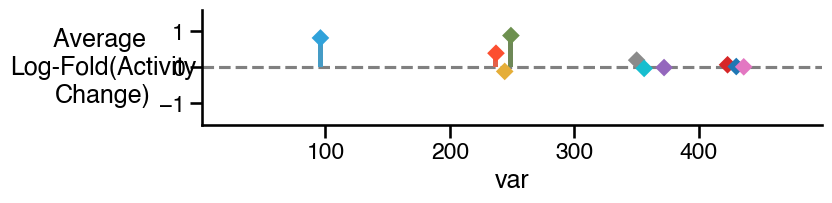

In [89]:
plt.figure(figsize = (8, 1.5))
plt.axhline(0, color = "gray", linestyle = "--", zorder = 0)

sns.barplot(data=PSv_confsA_STYA_vs_basic[["var", "activ_log_fold_change"]].groupby("var").mean(), 
                x="var", 
                y="activ_log_fold_change", 
                hue="var", 
                legend=False, 
                palette=palette,
                alpha=1, 
                edgecolor = "none", 
                native_scale = True)

sns.scatterplot(data=PSv_confsA_STYA_vs_basic[["var", "activ_log_fold_change"]].groupby("var").mean(), 
                x="var", 
                y="activ_log_fold_change", 
                hue="var", 
                legend=False, 
                palette=palette,
                alpha=1, marker = "D", edgecolor = "none")


plt.ylabel("Average \nLog-Fold(Activity\nChange)", rotation = 0, labelpad = 40, va = 'center')
sns.despine()
plt.xlim(1, 499)
plt.ylim(-1.6, 1.6)

In [92]:
PSv_confsA_STYA_vs_basic

,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,unweighted_std_var,...,Activity_S3_2_wt,lib2_avg_wt,unweighted_std_wt,weighted_std_wt,activ_err_start_wt,activ_err_end_wt,var,activ_diff,activ_fold_change,activ_log_fold_change
0,61,100,7_PSv_conf2sA_STYA,NaN,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,602.055974,567.661610,584.858792,773.857346,...,1517.695164,1245.706526,555.827682,439.055694,534.662195,1412.773583,96,-371.661915,0.618306,-0.480771
1,71,110,8_PSv_conf2sA_STYA,NaN,91,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,2092.472748,2127.003654,2109.738201,1215.818623,...,369.638636,466.350758,1913.448529,702.321334,-139.258453,1265.384214,96,1529.409868,3.716233,1.312710
2,81,120,9_PSv_conf2sA_STYA,NaN,101,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,1501.606009,1112.678850,1307.142429,2599.241727,...,1403.352788,1051.731838,1325.703495,375.390470,324.720418,1075.501358,96,801.495121,2.144812,0.763052
3,91,130,10_PSv_conf2sA_STYA,NaN,111,DEFIPAVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,2060.557652,1159.883146,1610.220399,NaN,...,1577.686428,984.194231,816.038487,105.284362,285.417672,495.986395,96,1669.855618,5.273988,1.662787
4,201,240,21_PSv_conf2sA_STYA,NaN,221,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVAPTA,1902.742141,2002.619268,1952.680704,1060.765917,...,412.457887,466.499666,1196.977215,424.880030,95.661415,945.421475,237,1382.200696,3.655313,1.296182
5,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVAPTADPVTPKLATP,494.376305,1460.060818,977.218561,877.877401,...,929.825007,865.083934,973.653282,313.691933,486.650926,1114.034793,237,-305.966555,0.617706,-0.481743
6,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVAPKLATP,421.516360,NaN,421.516360,606.417454,...,929.825007,865.083934,973.653282,313.691933,486.650926,1114.034793,244,-378.826499,0.526670,-0.641182
7,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLAAP,1183.433660,745.045022,964.239341,1135.360416,...,929.825007,865.083934,973.653282,313.691933,486.650926,1114.034793,249,383.090801,1.478658,0.391135
8,221,260,23_PSv_conf2sA_STYA,NaN,241,GDKAEQEVSEDIFAAVAPTADPVTPKLATPEPRNAVRICS,1342.346794,921.293405,1131.820099,143.063130,...,2265.337229,1429.122488,1718.395787,265.470468,327.437280,858.378215,237,749.439046,2.264006,0.817136
9,221,260,23_PSv_conf2sA_STYA,NaN,241,GDKAEQEVSEDIFAAVTPTADPVAPKLATPEPRNAVRICS,732.028805,NaN,732.028805,1660.611645,...,2265.337229,1429.122488,1718.395787,265.470468,327.437280,858.378215,244,139.121057,1.234642,0.210781


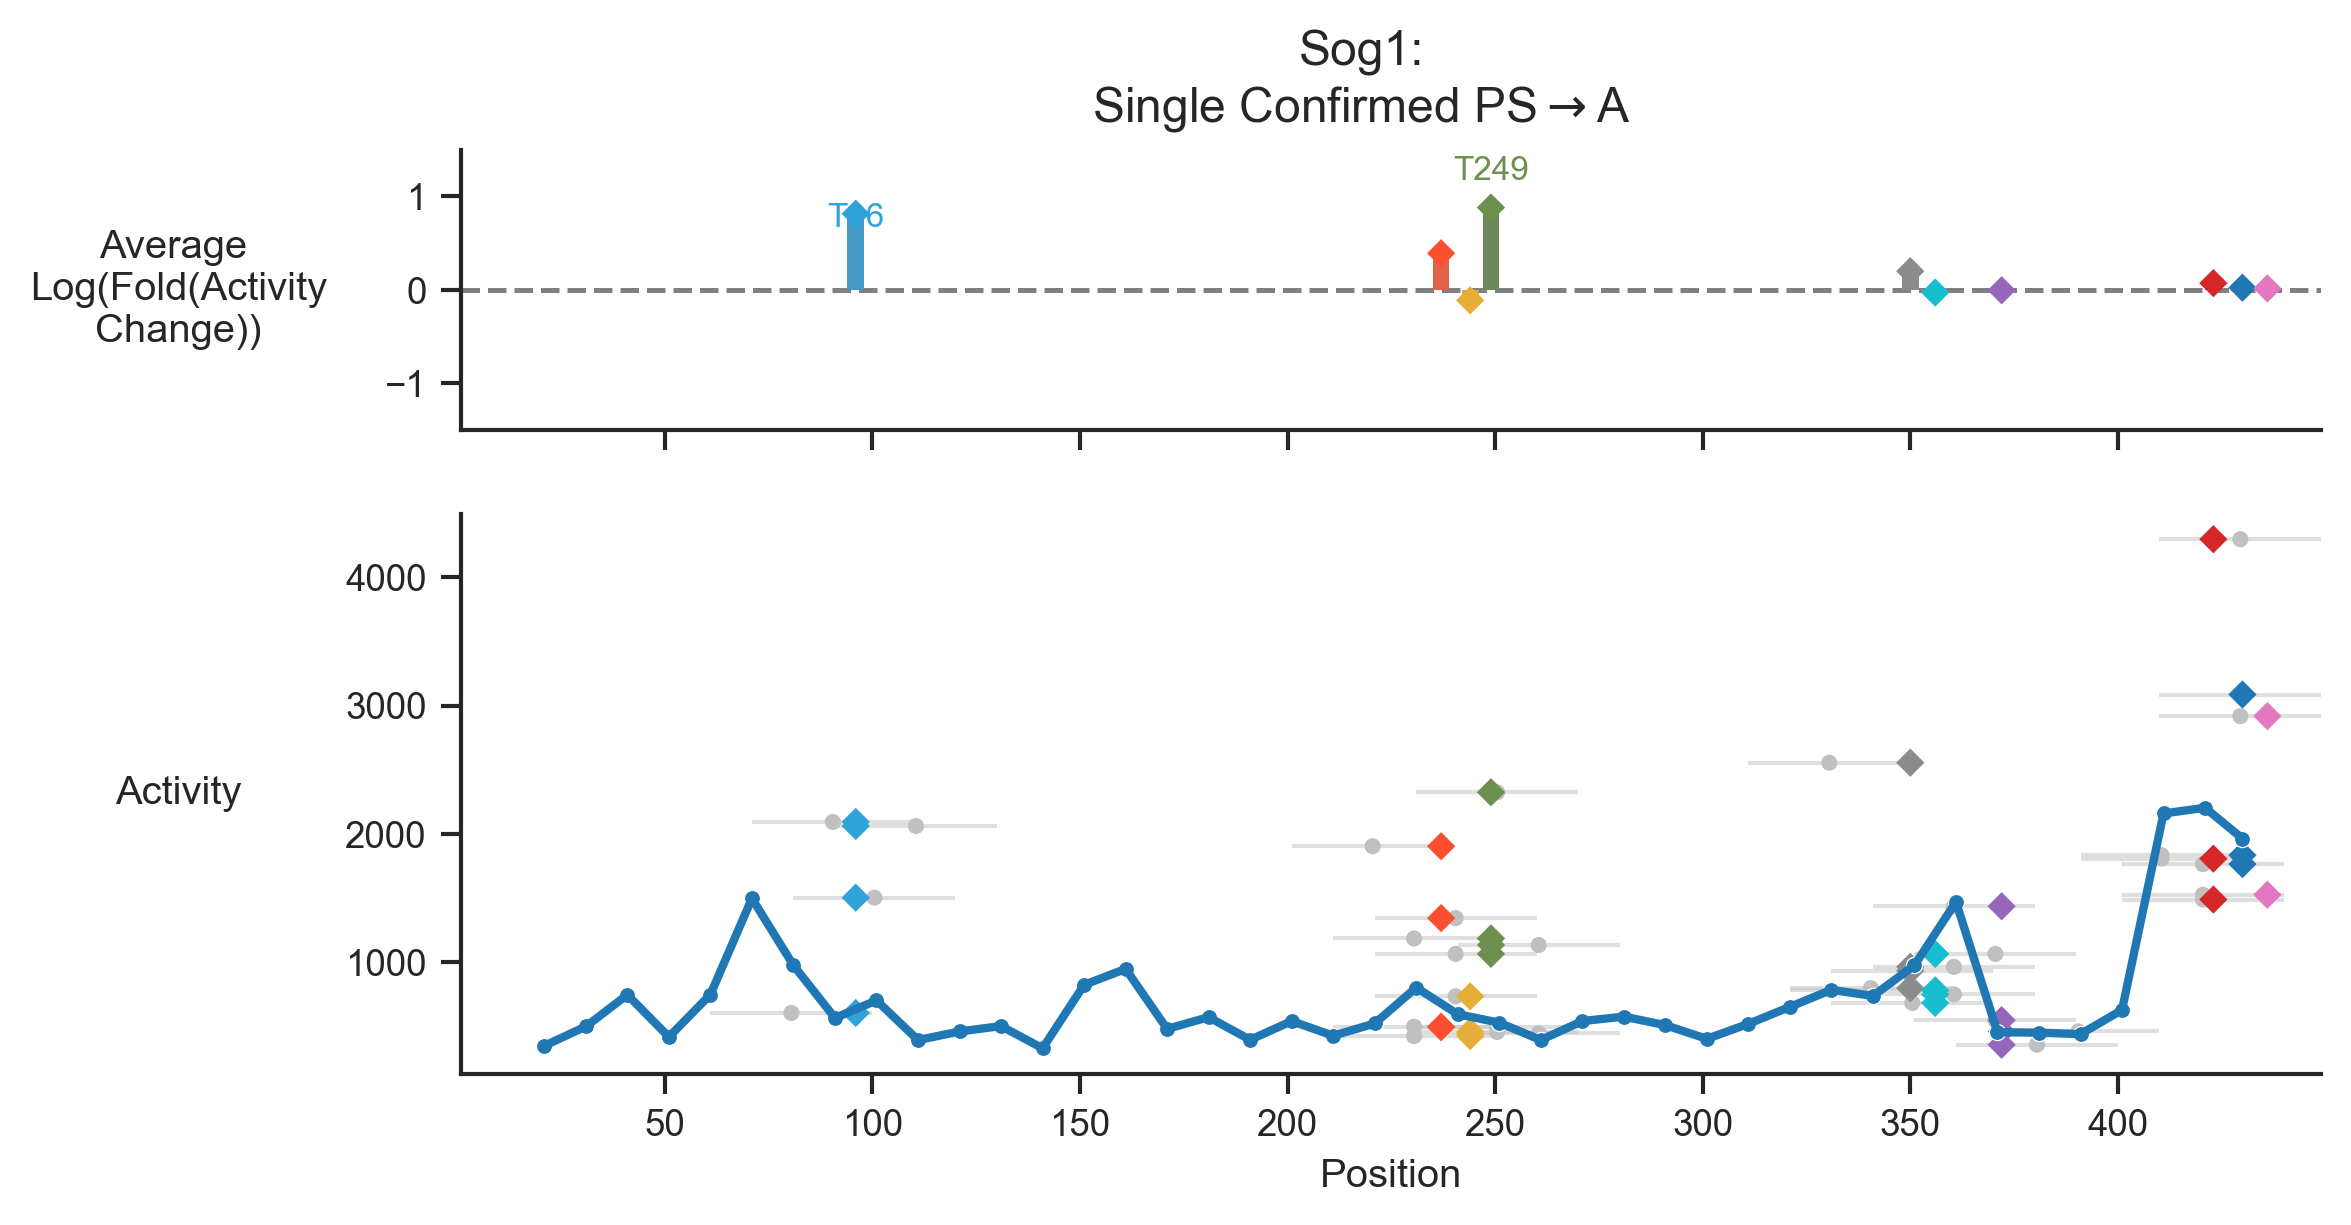

In [104]:
sns.set_context('paper')
sns.set_style('ticks')
# Create a 2-row subplot with shared x-axis
fig, axs = plt.subplots(2, 1, figsize=(8, 4), sharex=True, gridspec_kw = {'height_ratios' : [1, 2]}, dpi = 300)

# Plot part 1
# axs[0].axhline(y=0, color="black", zorder = 0, linestyle = "--", lw = 1)
# plot_all_tiles(PSv_confsA_STYA_vs_basic, 
#                "activ_log_fold_change", 
#                ax=axs[0], 
#                color='silver')

# sns.scatterplot(data=PSv_confsA_STYA_vs_basic, 
#                 x="var", 
#                 y="activ_log_fold_change", 
#                 hue="var", 
#                 legend=False, 
#                 palette='colorblind',
#                 alpha=1, ax=axs[0], marker = "D", edgecolor = "none")
# axs[0].set_ylabel("Log\n(Activity-fold\nChange)", rotation=0, labelpad=20, va="center")
# axs[0].set_xlim(1, 449)

# sns.despine(ax=axs[0])

axs[0].axhline(0, color = "gray", linestyle = "--", zorder = 0)

avg_log_fold = PSv_confsA_STYA_vs_basic[["var", "activ_log_fold_change"]].groupby("var").mean()
sns.barplot(data=avg_log_fold, 
                x="var", 
                y="activ_log_fold_change", 
                hue="var", 
                legend=False, 
                palette=palette,
                alpha=1, 
                edgecolor = "none", 
                native_scale = True, ax = axs[0])

sns.scatterplot(data=avg_log_fold, 
                x="var", 
                y="activ_log_fold_change", 
                hue="var", 
                legend=False, 
                palette=palette,
                alpha=1, marker = "D", edgecolor = "none", ax = axs[0])


axs[0].set_ylabel("Average \nLog(Fold(Activity\nChange))", rotation = 0, labelpad = 40, va = 'center')
sns.despine(ax = axs[0])
axs[0].set_xlim(1, 499)
axs[0].set_ylim(-1.5, 1.5)

axs[0].text(96, 0.6, s = r"T96", ha = "center", va = "bottom", fontsize = 'small', color = palette[0])
axs[0].text(249, 1.1, s = r"T249", ha = "center", va = "bottom", fontsize = 'small', color = palette[3])
#axs[0].text(273, 0.5, s = r"$\bigstar$T273", ha = "center", va = "bottom", fontsize = 'small')

#axs[0].legend(bbox_to_anchor = (1.2,1.4), title = "   Mutated\nPhosphosite")

# Plot part 2
sog1_helpers.plot_all_tiles(PSv_confsA_STYA_vs_basic, activity_col + "_var", ax=axs[1], color='silver')
sns.scatterplot(data=PSv_confsA_STYA_vs_basic, 
                x="var", 
                y=activity_col + "_var", 
                hue="var", 
                legend=False, 
                palette=palette,
                alpha=1, ax=axs[1], marker = "D", edgecolor = "none")

sns.lineplot(data=BasicArTh, x="mid", y=activity_col, label="WT Tiles", lw=2, ax=axs[1], legend = False)

sns.scatterplot(data=BasicArTh, 
                x="mid", 
                y=activity_col, 
                legend=False, 
                alpha=1, 
                ax=axs[1], 
                color = sns.color_palette('tab10')[0], 
                s = 15)


axs[1].set_xlim(1, 449)
axs[1].set_ylabel("Activity", rotation = 0, labelpad = 40, va = 'center')
axs[1].set_xlabel("Position")
sns.despine(ax=axs[1])
#axs[1].legend(bbox_to_anchor = (1.22, 0.1), labelspacing = 0)

# Adjust layout for better spacing

fig.align_ylabels(axs)
plt.suptitle("Sog1:\nSingle Confirmed PS$\\rightarrow$A")
#plt.tight_layout()
# Show the figure
plt.show()


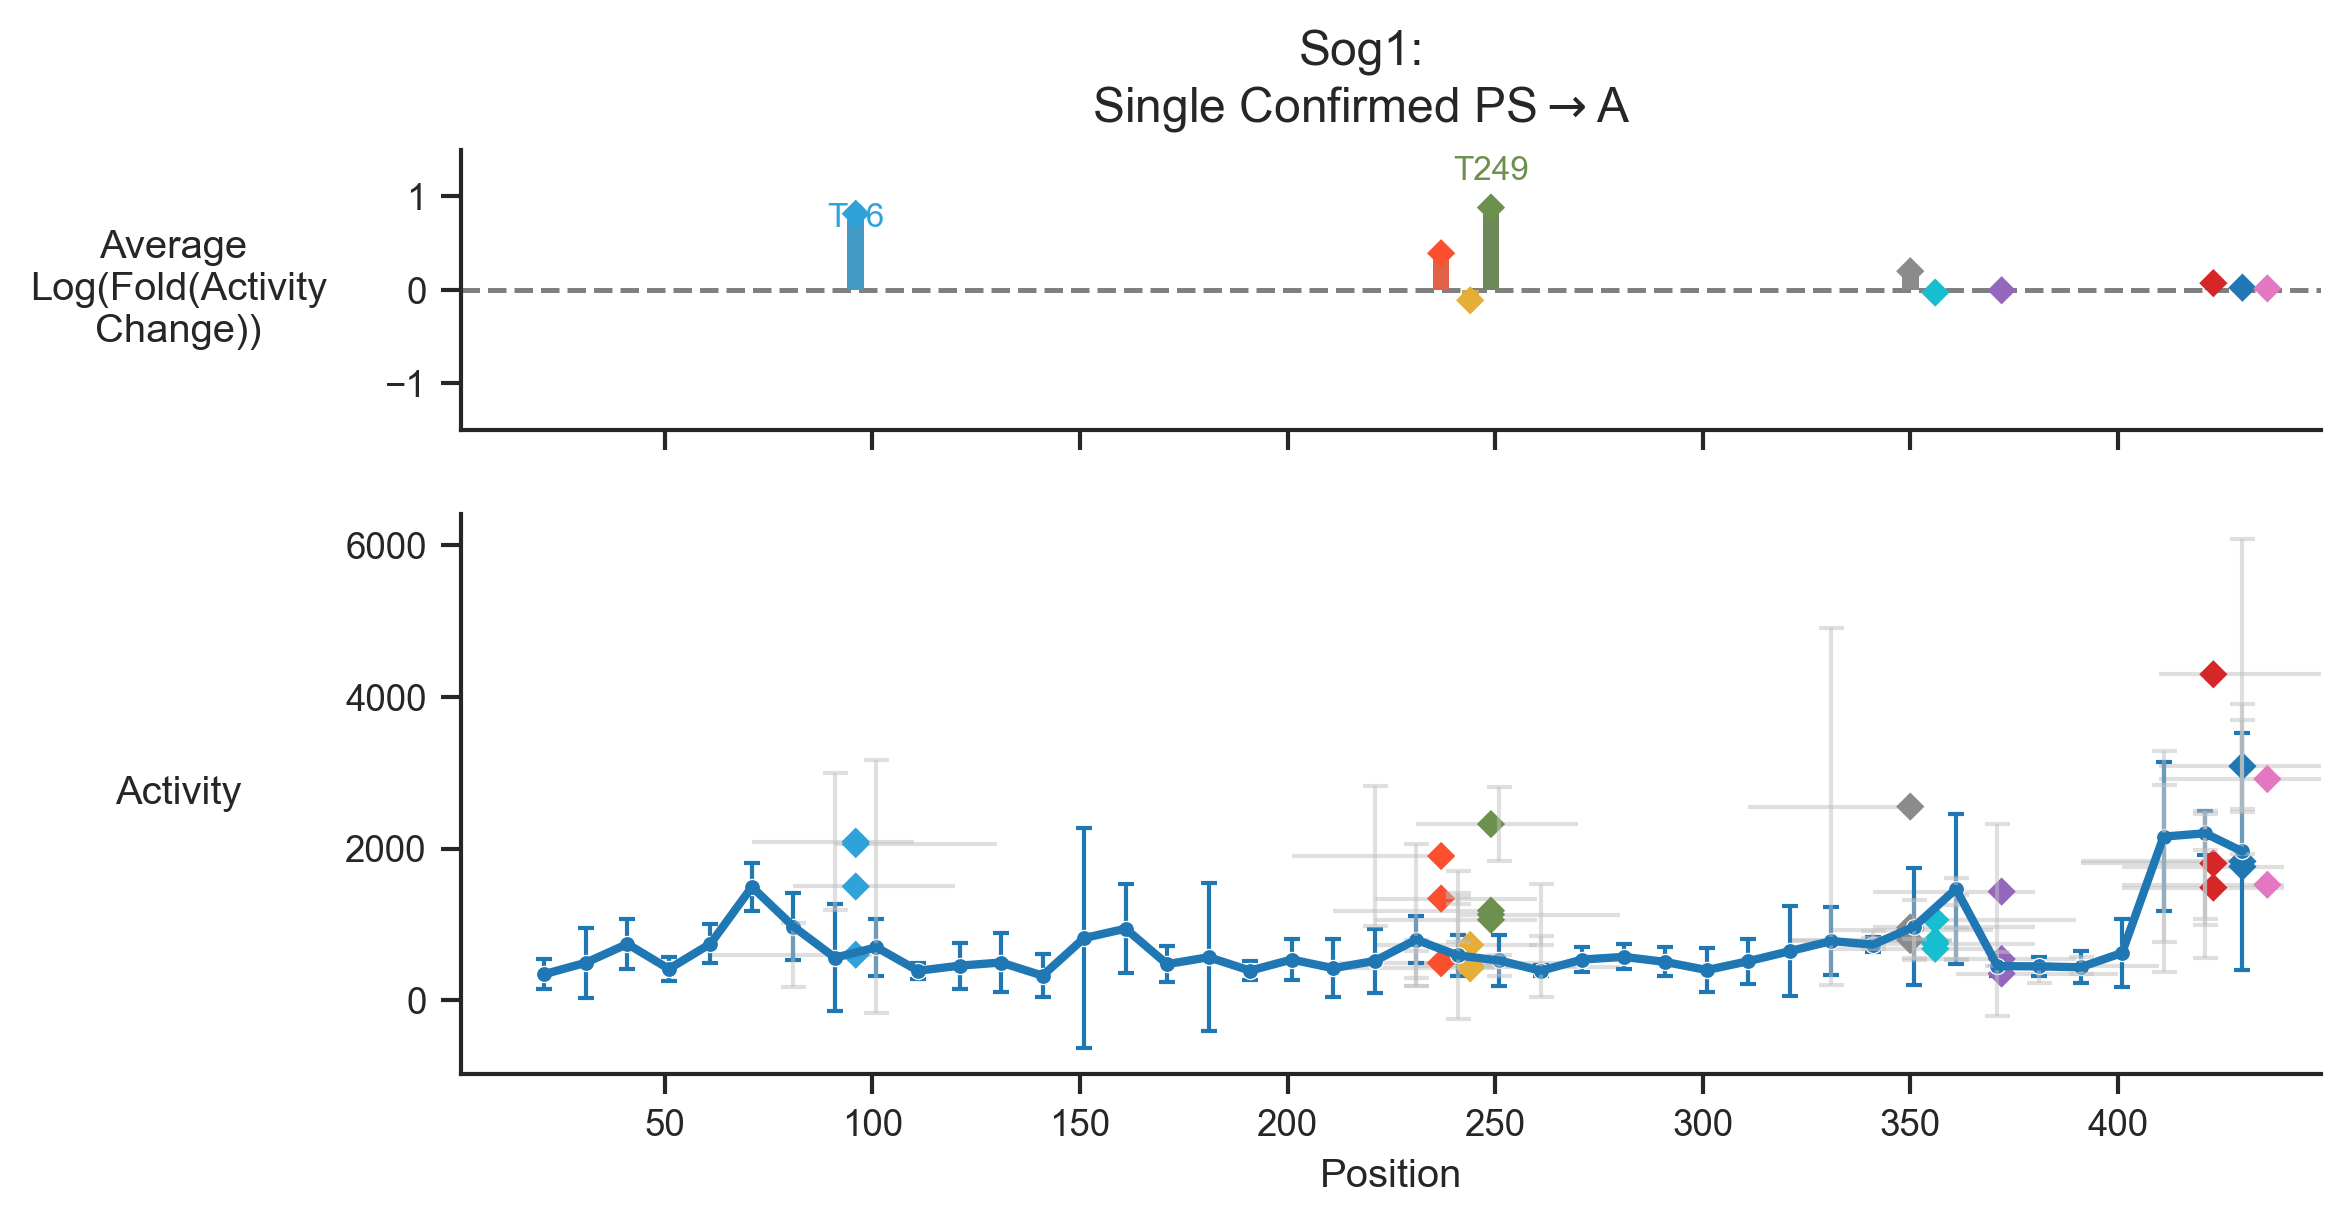

In [105]:
sns.set_context('paper')
sns.set_style('ticks')
# Create a 2-row subplot with shared x-axis
fig, axs = plt.subplots(2, 1, figsize=(8, 4), sharex=True, gridspec_kw = {'height_ratios' : [1, 2]}, dpi = 300)

# Plot part 1
# axs[0].axhline(y=0, color="black", zorder = 0, linestyle = "--", lw = 1)
# plot_all_tiles(PSv_confsA_STYA_vs_basic, 
#                "activ_log_fold_change", 
#                ax=axs[0], 
#                color='silver')

# sns.scatterplot(data=PSv_confsA_STYA_vs_basic, 
#                 x="var", 
#                 y="activ_log_fold_change", 
#                 hue="var", 
#                 legend=False, 
#                 palette='colorblind',
#                 alpha=1, ax=axs[0], marker = "D", edgecolor = "none")
# axs[0].set_ylabel("Log\n(Activity-fold\nChange)", rotation=0, labelpad=20, va="center")
# axs[0].set_xlim(1, 449)

# sns.despine(ax=axs[0])

axs[0].axhline(0, color = "gray", linestyle = "--", zorder = 0)

avg_log_fold = PSv_confsA_STYA_vs_basic[["var", "activ_log_fold_change"]].groupby("var").mean()
sns.barplot(data=avg_log_fold, 
                x="var", 
                y="activ_log_fold_change", 
                hue="var", 
                legend=False, 
                palette=palette,
                alpha=1, 
                edgecolor = "none", 
                native_scale = True, ax = axs[0])

sns.scatterplot(data=avg_log_fold, 
                x="var", 
                y="activ_log_fold_change", 
                hue="var", 
                legend=False, 
                palette=palette,
                alpha=1, marker = "D", edgecolor = "none", ax = axs[0])


axs[0].set_ylabel("Average \nLog(Fold(Activity\nChange))", rotation = 0, labelpad = 40, va = 'center')
sns.despine(ax = axs[0])
axs[0].set_xlim(1, 499)
axs[0].set_ylim(-1.5, 1.5)

axs[0].text(96, 0.6, s = r"T96", ha = "center", va = "bottom", fontsize = 'small', color = palette[0])
axs[0].text(249, 1.1, s = r"T249", ha = "center", va = "bottom", fontsize = 'small', color = palette[3])
#axs[0].text(273, 0.5, s = r"$\bigstar$T273", ha = "center", va = "bottom", fontsize = 'small')

#axs[0].legend(bbox_to_anchor = (1.2,1.4), title = "   Mutated\nPhosphosite")

# Plot part 2
sog1_helpers.plot_all_tiles(PSv_confsA_STYA_vs_basic, activity_col + "_var", ax=axs[1], color='silver', center = False)

plt.errorbar(PSv_confsA_STYA_vs_basic["mid"], 
             PSv_confsA_STYA_vs_basic["Activity_S3_1_var"], 
             yerr=[PSv_confsA_STYA_vs_basic["weighted_std_var"], PSv_confsA_STYA_vs_basic["weighted_std_var"]], 
             fmt='none', 
             ecolor='silver', 
             elinewidth=1, 
             capsize=3, 
             zorder = 2, alpha = 0.5)

sns.scatterplot(data=PSv_confsA_STYA_vs_basic, 
                x="var", 
                y=activity_col + "_var", 
                hue="var", 
                legend=False, 
                palette=palette,
                alpha=1, ax=axs[1], marker = "D", edgecolor = "none")

sns.lineplot(data=BasicArTh, x="mid", y=activity_col, label="WT Tiles", lw=2, ax=axs[1], legend = False)
plt.errorbar(BasicArTh["mid"], 
             BasicArTh["Activity_S3_1"], 
             yerr=[BasicArTh["weighted_std"], BasicArTh["weighted_std"]], 
             fmt='none', 
             ecolor=sns.color_palette('tab10')[0], 
             elinewidth=1, 
             capsize=2, 
             zorder = 0)

sns.scatterplot(data=BasicArTh, 
                x="mid", 
                y=activity_col, 
                legend=False, 
                alpha=1, 
                ax=axs[1], 
                color = sns.color_palette('tab10')[0], 
                s = 15)


axs[1].set_xlim(1, 449)
axs[1].set_ylabel("Activity", rotation = 0, labelpad = 40, va = 'center')
axs[1].set_xlabel("Position")
sns.despine(ax=axs[1])
#axs[1].legend(bbox_to_anchor = (1.22, 0.1), labelspacing = 0)

# Adjust layout for better spacing

fig.align_ylabels(axs)
plt.suptitle("Sog1:\nSingle Confirmed PS$\\rightarrow$A")
#plt.tight_layout()
# Show the figure
plt.show()


# 3. Are there non-confirmed PS that contribute to activity?

# 4. Is there an ordering when phosphorylation matters?

In [18]:
PSv_conf2cA_STYA = sog1_helpers.return_activities("PSv_conf2cA_STYA")
PSv_conf2cA_STYA.head(3)

,Start,End,Description,Other,mid,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,61,100,7_PSv_conf2cA_STYA,NaN,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,602.055974,567.661610,584.858792
1,71,110,8_PSv_conf2cA_STYA,NaN,91,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,2092.472748,2127.003654,2109.738201
2,81,120,9_PSv_conf2cA_STYA,NaN,101,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,1501.606009,1112.678850,1307.142429


In [19]:
PSv_conf2cA_STYA_vs_basic = sog1_helpers.add_all_var_positions(PSv_conf2cA_STYA, BasicArTh, activity_col)
PSv_conf2cA_STYA_vs_basic

,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,Description_wt,Other_wt,tile_wt,Activity_S3_1_wt,Activity_S3_2_wt,lib2_avg_wt,vars
0,61,100,7_PSv_conf2cA_STYA,NaN,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,602.055974,567.661610,584.858792,BasicArTh.7,Q6NQK2,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQD,973.717889,1517.695164,1245.706526,[96]
1,71,110,8_PSv_conf2cA_STYA,NaN,91,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,2092.472748,2127.003654,2109.738201,BasicArTh.8,Q6NQK2,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,563.062881,369.638636,466.350758,[96]
2,81,120,9_PSv_conf2cA_STYA,NaN,101,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,1501.606009,1112.678850,1307.142429,BasicArTh.9,Q6NQK2,LSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTV,700.110888,1403.352788,1051.731838,[96]
3,91,130,10_PSv_conf2cA_STYA,NaN,111,DEFIPAVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,2060.557652,1159.883146,1610.220399,BasicArTh.10,Q6NQK2,DEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,390.702034,1577.686428,984.194231,[96]
4,201,240,21_PSv_conf2cA_STYA,NaN,221,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVAPTA,1902.742141,2002.619268,1952.680704,BasicArTh.21,Q6NQK2,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVTPTA,520.541445,412.457887,466.499666,[237]
5,211,250,22_PSv_conf2cA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVAPTADPVAPKLATP,360.521613,265.620802,313.071208,BasicArTh.22,Q6NQK2,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATP,800.342860,929.825007,865.083934,"[237, 244]"
6,211,250,22_PSv_conf2cA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVAPTADPVTPKLAAP,1721.673160,1254.145149,1487.909154,BasicArTh.22,Q6NQK2,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATP,800.342860,929.825007,865.083934,"[237, 249]"
7,211,250,22_PSv_conf2cA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVAPKLAAP,1217.836043,1092.692938,1155.264490,BasicArTh.22,Q6NQK2,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATP,800.342860,929.825007,865.083934,"[244, 249]"
8,211,250,22_PSv_conf2cA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVAPTADPVAPKLAAP,3450.490926,3241.749707,3346.120317,BasicArTh.22,Q6NQK2,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATP,800.342860,929.825007,865.083934,"[237, 244, 249]"
9,221,260,23_PSv_conf2cA_STYA,NaN,241,GDKAEQEVSEDIFAAVAPTADPVAPKLATPEPRNAVRICS,1208.074819,1616.549590,1412.312205,BasicArTh.23,Q6NQK2,GDKAEQEVSEDIFAAVTPTADPVTPKLATPEPRNAVRICS,592.907748,2265.337229,1429.122488,"[237, 244]"


In [20]:
PSv_conf2cA_STYA_vs_basic["vars"].value_counts()

vars
[96]               4
[244, 249]         4
[237, 244]         3
[237, 249]         3
[237, 244, 249]    3
[350, 356]         3
[423, 430]         3
[356, 372]         2
[372]              2
[423, 436]         2
[430, 436]         2
[423, 430, 436]    2
[237]              1
[350]              1
[350, 372]         1
[350, 356, 372]    1
Name: count, dtype: int64

In [21]:
PSv_conf2cA_STYA_vs_basic["Start"].value_counts()

Start
410    4
401    4
211    4
221    4
231    4
341    4
331    1
391    1
371    1
361    1
351    1
61     1
321    1
71     1
241    1
201    1
91     1
81     1
311    1
Name: count, dtype: int64

In [22]:
PSv_conf2cA_STYA_vs_basic["vars_str"] = PSv_conf2cA_STYA_vs_basic["vars"].astype(str)
PSv_conf2cA_STYA_vs_basic["var_count"] = PSv_conf2cA_STYA_vs_basic["vars_str"].str.count(",") + 1
PSv_conf2cA_STYA_vs_basic[["Start", "vars_str"]].value_counts()

Start  vars_str       
61     [96]               1
321    [350, 356]         1
341    [350, 356, 372]    1
       [350, 356]         1
       [350, 372]         1
       [356, 372]         1
351    [356, 372]         1
361    [372]              1
371    [372]              1
391    [423, 430]         1
401    [423, 430, 436]    1
       [423, 430]         1
       [423, 436]         1
       [430, 436]         1
410    [423, 430, 436]    1
       [423, 430]         1
       [423, 436]         1
331    [350, 356]         1
311    [350]              1
71     [96]               1
241    [244, 249]         1
81     [96]               1
91     [96]               1
201    [237]              1
211    [237, 244, 249]    1
       [237, 244]         1
       [237, 249]         1
       [244, 249]         1
221    [237, 244, 249]    1
       [237, 244]         1
       [237, 249]         1
       [244, 249]         1
231    [237, 244, 249]    1
       [237, 244]         1
       [237, 249]        

In [23]:
PSv_conf2sA_STYA = sog1_helpers.return_activities("PSv_conf2sA_STYA")
PSv_conf2sA_STYA_vs_basic = sog1_helpers.add_var_positions(PSv_conf2sA_STYA, BasicArTh, activity_col)
PSv_conf2sA_STYA_vs_basic

,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,Description_wt,Other_wt,tile_wt,Activity_S3_1_wt,Activity_S3_2_wt,lib2_avg_wt,var,activ_diff,activ_fold_change
0,61,100,7_PSv_conf2sA_STYA,NaN,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,602.055974,567.661610,584.858792,BasicArTh.7,Q6NQK2,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQD,973.717889,1517.695164,1245.706526,96,-371.661915,0.618306
1,71,110,8_PSv_conf2sA_STYA,NaN,91,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,2092.472748,2127.003654,2109.738201,BasicArTh.8,Q6NQK2,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,563.062881,369.638636,466.350758,96,1529.409868,3.716233
2,81,120,9_PSv_conf2sA_STYA,NaN,101,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,1501.606009,1112.678850,1307.142429,BasicArTh.9,Q6NQK2,LSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTV,700.110888,1403.352788,1051.731838,96,801.495121,2.144812
3,91,130,10_PSv_conf2sA_STYA,NaN,111,DEFIPAVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,2060.557652,1159.883146,1610.220399,BasicArTh.10,Q6NQK2,DEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,390.702034,1577.686428,984.194231,96,1669.855618,5.273988
4,201,240,21_PSv_conf2sA_STYA,NaN,221,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVAPTA,1902.742141,2002.619268,1952.680704,BasicArTh.21,Q6NQK2,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVTPTA,520.541445,412.457887,466.499666,237,1382.200696,3.655313
5,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVAPTADPVTPKLATP,494.376305,1460.060818,977.218561,BasicArTh.22,Q6NQK2,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATP,800.342860,929.825007,865.083934,237,-305.966555,0.617706
6,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVAPKLATP,421.516360,NaN,421.516360,BasicArTh.22,Q6NQK2,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATP,800.342860,929.825007,865.083934,244,-378.826499,0.526670
7,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLAAP,1183.433660,745.045022,964.239341,BasicArTh.22,Q6NQK2,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATP,800.342860,929.825007,865.083934,249,383.090801,1.478658
8,221,260,23_PSv_conf2sA_STYA,NaN,241,GDKAEQEVSEDIFAAVAPTADPVTPKLATPEPRNAVRICS,1342.346794,921.293405,1131.820099,BasicArTh.23,Q6NQK2,GDKAEQEVSEDIFAAVTPTADPVTPKLATPEPRNAVRICS,592.907748,2265.337229,1429.122488,237,749.439046,2.264006
9,221,260,23_PSv_conf2sA_STYA,NaN,241,GDKAEQEVSEDIFAAVTPTADPVAPKLATPEPRNAVRICS,732.028805,NaN,732.028805,BasicArTh.23,Q6NQK2,GDKAEQEVSEDIFAAVTPTADPVTPKLATPEPRNAVRICS,592.907748,2265.337229,1429.122488,244,139.121057,1.234642


In [24]:
plt.rcParams['text.usetex'] = False

In [25]:
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(4, 9), dpi = 300)
# sog1_helpers.plot_combination_activities(211, ax1, PSv_conf2cA_STYA_vs_basic)
# sog1_helpers.plot_combination_activities(221, ax2, PSv_conf2cA_STYA_vs_basic)
# sog1_helpers.plot_combination_activities(231, ax3, PSv_conf2cA_STYA_vs_basic)

In [26]:
PSv_conf2cA_STYA_vs_basic

,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,Description_wt,Other_wt,tile_wt,Activity_S3_1_wt,Activity_S3_2_wt,lib2_avg_wt,vars,vars_str,var_count
0,61,100,7_PSv_conf2cA_STYA,NaN,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,602.055974,567.661610,584.858792,BasicArTh.7,Q6NQK2,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQD,973.717889,1517.695164,1245.706526,[96],[96],1
1,71,110,8_PSv_conf2cA_STYA,NaN,91,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,2092.472748,2127.003654,2109.738201,BasicArTh.8,Q6NQK2,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,563.062881,369.638636,466.350758,[96],[96],1
2,81,120,9_PSv_conf2cA_STYA,NaN,101,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,1501.606009,1112.678850,1307.142429,BasicArTh.9,Q6NQK2,LSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTV,700.110888,1403.352788,1051.731838,[96],[96],1
3,91,130,10_PSv_conf2cA_STYA,NaN,111,DEFIPAVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,2060.557652,1159.883146,1610.220399,BasicArTh.10,Q6NQK2,DEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,390.702034,1577.686428,984.194231,[96],[96],1
4,201,240,21_PSv_conf2cA_STYA,NaN,221,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVAPTA,1902.742141,2002.619268,1952.680704,BasicArTh.21,Q6NQK2,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVTPTA,520.541445,412.457887,466.499666,[237],[237],1
5,211,250,22_PSv_conf2cA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVAPTADPVAPKLATP,360.521613,265.620802,313.071208,BasicArTh.22,Q6NQK2,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATP,800.342860,929.825007,865.083934,"[237, 244]","[237, 244]",2
6,211,250,22_PSv_conf2cA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVAPTADPVTPKLAAP,1721.673160,1254.145149,1487.909154,BasicArTh.22,Q6NQK2,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATP,800.342860,929.825007,865.083934,"[237, 249]","[237, 249]",2
7,211,250,22_PSv_conf2cA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVAPKLAAP,1217.836043,1092.692938,1155.264490,BasicArTh.22,Q6NQK2,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATP,800.342860,929.825007,865.083934,"[244, 249]","[244, 249]",2
8,211,250,22_PSv_conf2cA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVAPTADPVAPKLAAP,3450.490926,3241.749707,3346.120317,BasicArTh.22,Q6NQK2,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATP,800.342860,929.825007,865.083934,"[237, 244, 249]","[237, 244, 249]",3
9,221,260,23_PSv_conf2cA_STYA,NaN,241,GDKAEQEVSEDIFAAVAPTADPVAPKLATPEPRNAVRICS,1208.074819,1616.549590,1412.312205,BasicArTh.23,Q6NQK2,GDKAEQEVSEDIFAAVTPTADPVTPKLATPEPRNAVRICS,592.907748,2265.337229,1429.122488,"[237, 244]","[237, 244]",2


In [27]:
PSv_conf2cA_STYA_vs_basic[PSv_conf2cA_STYA_vs_basic["Start"] == 341]

,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,Description_wt,Other_wt,tile_wt,Activity_S3_1_wt,Activity_S3_2_wt,lib2_avg_wt,vars,vars_str,var_count
21,341,380,35_PSv_conf2cA_STYA,NaN,361,EDPTWFDSGAQFILNAQQLVEALSLCDDLLGSQDREENTN,527.008623,NaN,527.008623,BasicArTh.35,Q6NQK2,EDPTWFDSGSQFILNSQQLVEALSLCDDLLGSQDREENTN,1468.633259,1276.338269,1372.485764,"[350, 356]","[350, 356]",2
22,341,380,35_PSv_conf2cA_STYA,NaN,361,EDPTWFDSGAQFILNSQQLVEALSLCDDLLGAQDREENTN,953.635664,NaN,953.635664,BasicArTh.35,Q6NQK2,EDPTWFDSGSQFILNSQQLVEALSLCDDLLGSQDREENTN,1468.633259,1276.338269,1372.485764,"[350, 372]","[350, 372]",2
23,341,380,35_PSv_conf2cA_STYA,NaN,361,EDPTWFDSGSQFILNAQQLVEALSLCDDLLGAQDREENTN,799.961654,NaN,799.961654,BasicArTh.35,Q6NQK2,EDPTWFDSGSQFILNSQQLVEALSLCDDLLGSQDREENTN,1468.633259,1276.338269,1372.485764,"[356, 372]","[356, 372]",2
24,341,380,35_PSv_conf2cA_STYA,NaN,361,EDPTWFDSGAQFILNAQQLVEALSLCDDLLGAQDREENTN,1057.622029,885.595129,971.608579,BasicArTh.35,Q6NQK2,EDPTWFDSGSQFILNSQQLVEALSLCDDLLGSQDREENTN,1468.633259,1276.338269,1372.485764,"[350, 356, 372]","[350, 356, 372]",3


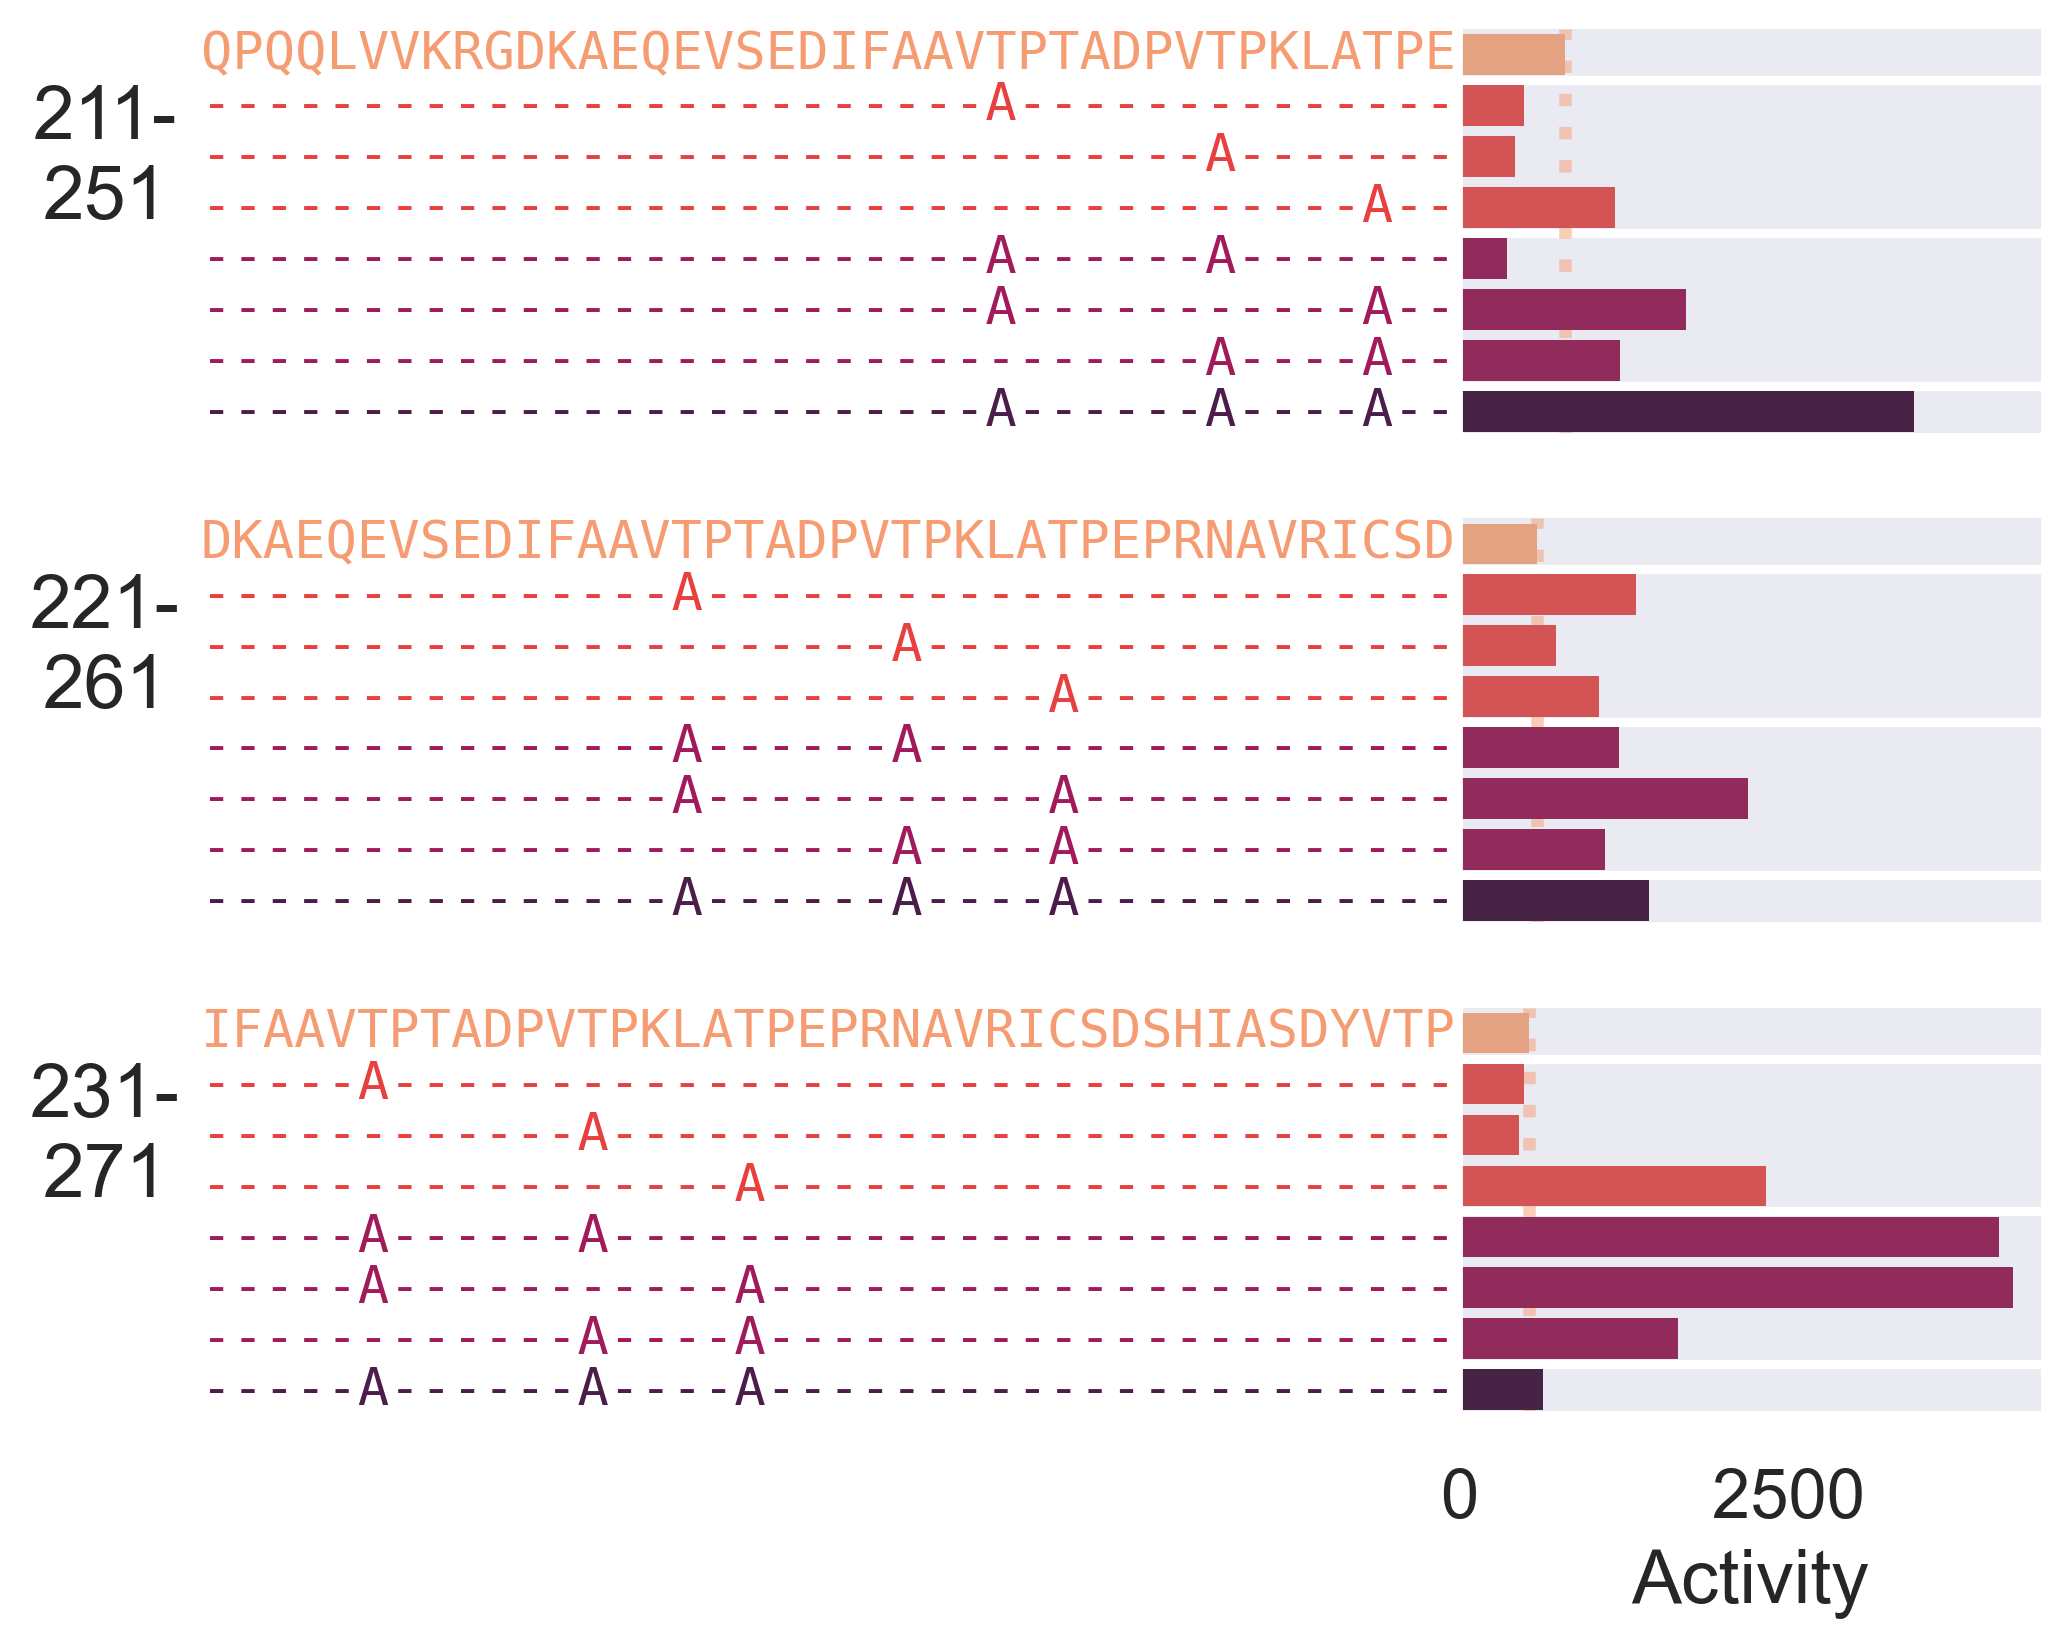

In [30]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(2.5, 6), dpi = 300)
sog1_helpers.plot_combination_activities(211, ax1, PSv_conf2cA_STYA_vs_basic, PSv_conf2sA_STYA_vs_basic)
sog1_helpers.plot_combination_activities(221, ax2, PSv_conf2cA_STYA_vs_basic, PSv_conf2sA_STYA_vs_basic)
sog1_helpers.plot_combination_activities(231, ax3, PSv_conf2cA_STYA_vs_basic, PSv_conf2sA_STYA_vs_basic)

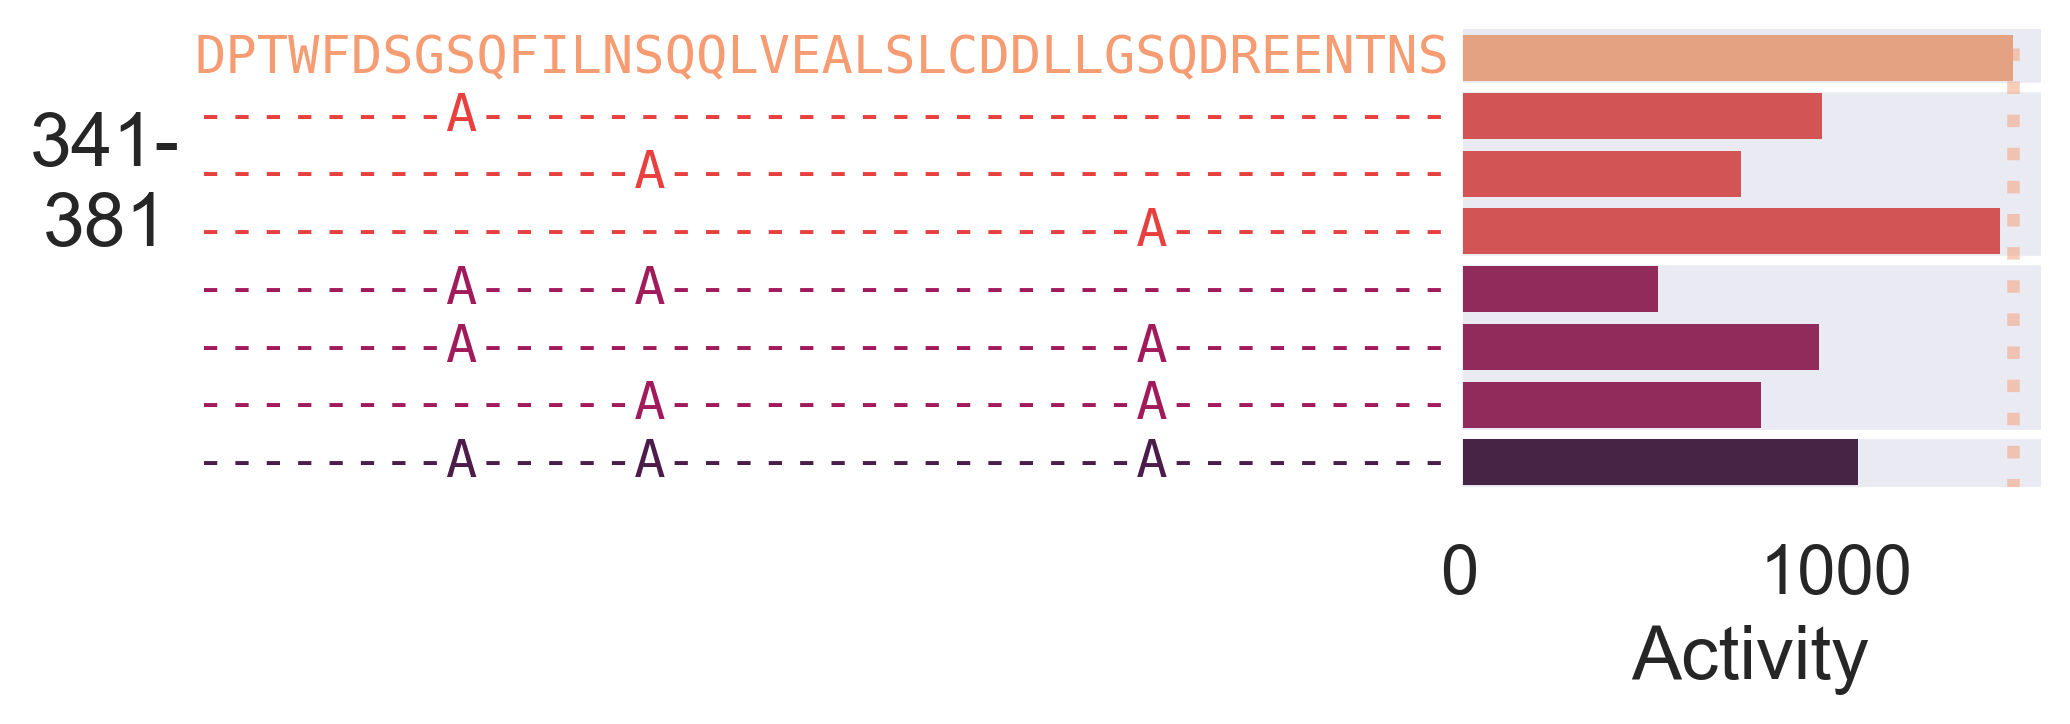

In [31]:
fig, (ax1) = plt.subplots(1, 1, sharex=True, figsize=(2.5, 2), dpi = 300)
sog1_helpers.plot_combination_activities(341, ax1, PSv_conf2cA_STYA_vs_basic, PSv_conf2sA_STYA_vs_basic)

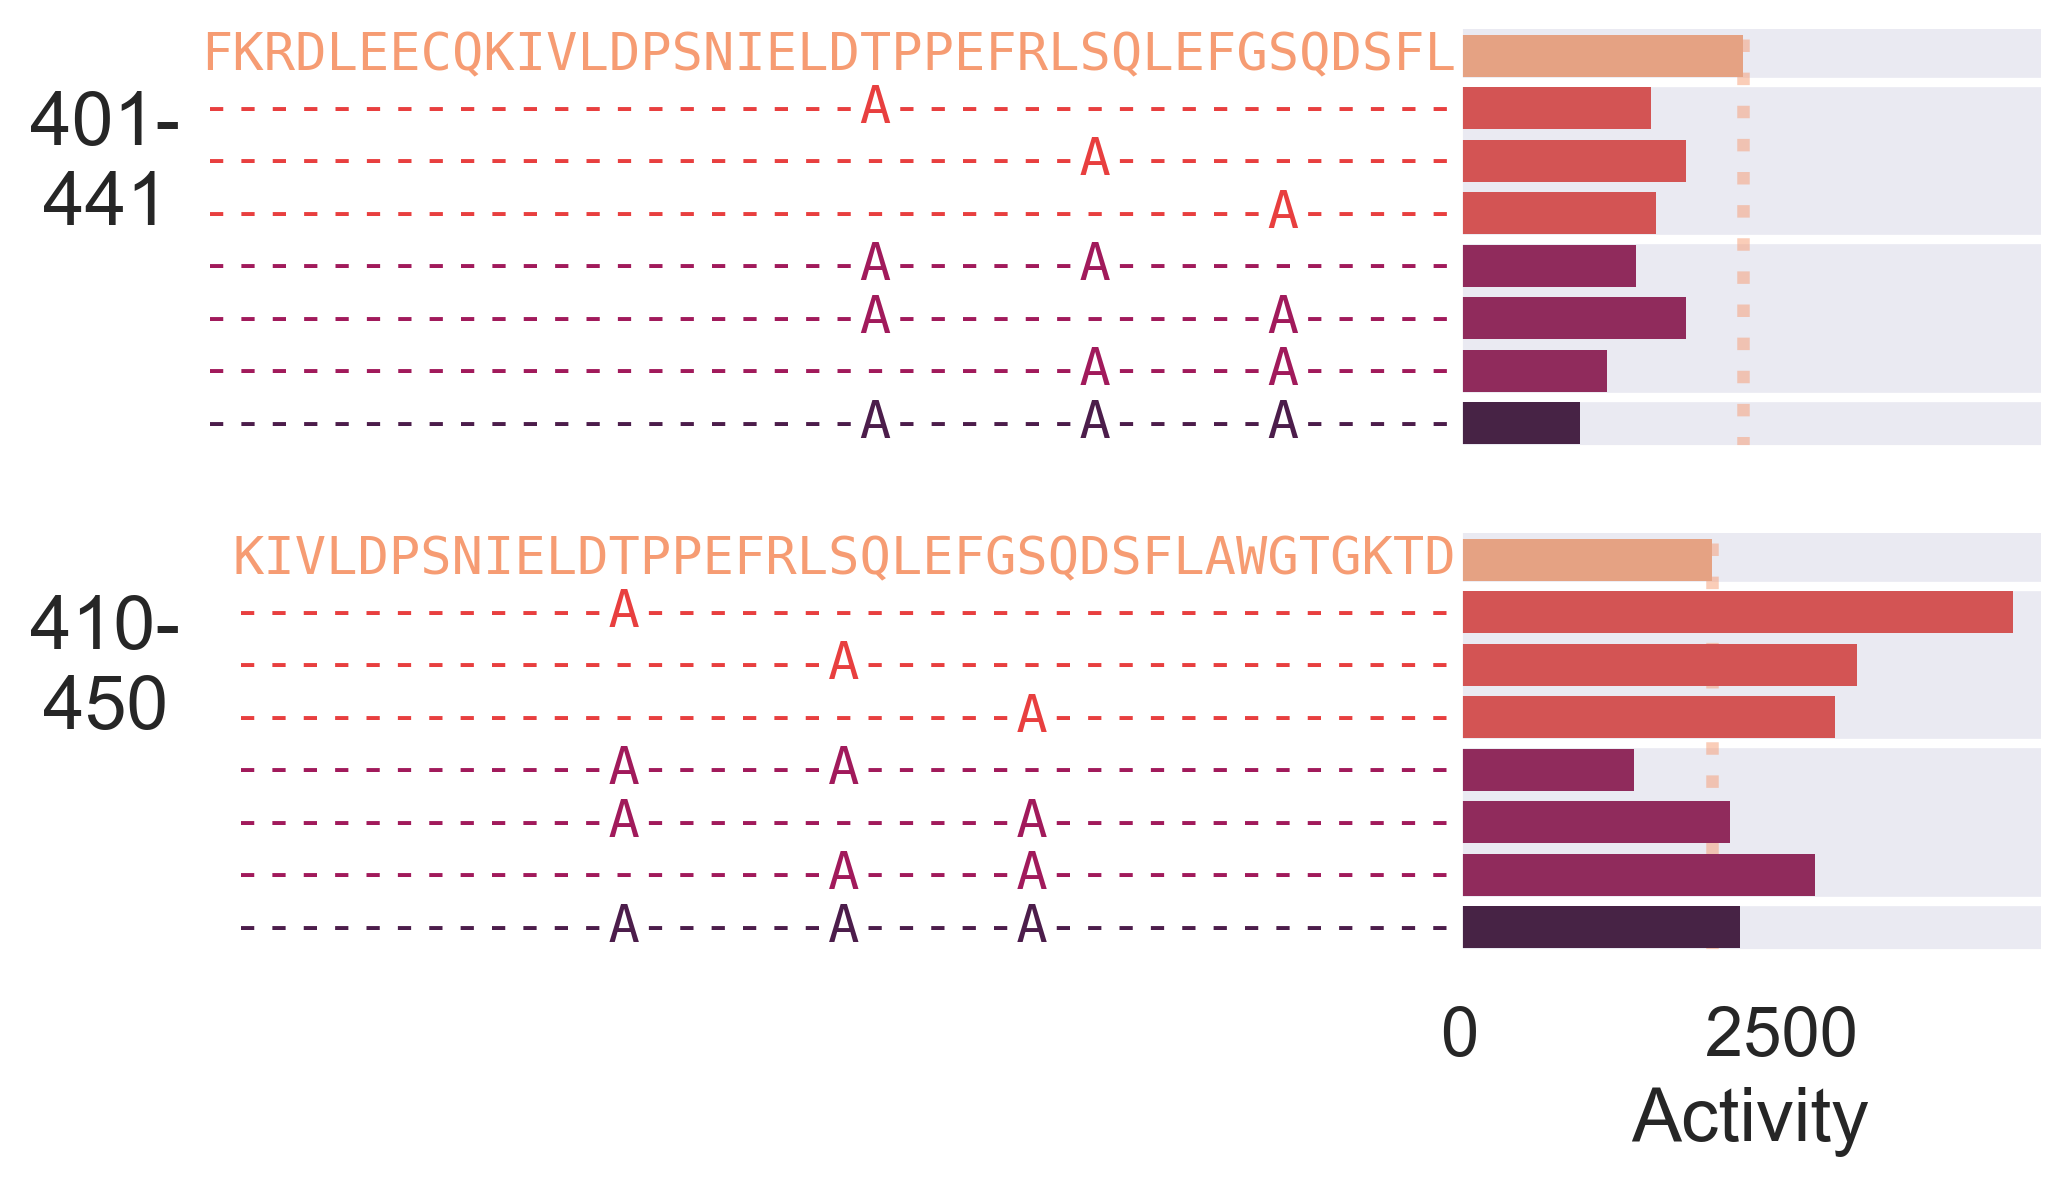

In [32]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(2.5, 4), dpi = 300)
sog1_helpers.plot_combination_activities(401, ax1, PSv_conf2cA_STYA_vs_basic, PSv_conf2sA_STYA_vs_basic)
sog1_helpers.plot_combination_activities(410, ax2, PSv_conf2cA_STYA_vs_basic, PSv_conf2sA_STYA_vs_basic)

# 5. Does the presence/lack of the aromatic ring in the substituent (Ala versus Phe) alter the outcome? 

## 5.1 Scatter plot of A1a vs A2a


In [74]:
PSv_max2A_STYA = return_activities("PSv_max2A_STYA")
PSv_max2A_STYA.head(3)

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,1_PSv_max2A_STYA,NaN,1,21,41,MAGRAWLIDANRIAAKIMAAAAAADPRQVVWKANPARHCP,732.778547,1942.091804,1337.435175
1,2_PSv_max2A_STYA,NaN,11,31,51,NRIAAKIMAAAAAADPRQVVWKANPARHCPKCQHVIDNAD,848.120638,870.053071,859.086855
2,3_PSv_max2A_STYA,NaN,21,41,61,AAAADPRQVVWKANPARHCPKCQHVIDNADVVDDWPGLPR,1607.930351,1915.041738,1761.486045


In [75]:
PSv_max2A_STYA = add_var_positions(PSv_max2A_STYA, BasicArTh, activity_col)
PSv_max2A_STYA.head(3)

,Description_var,Other_var,Start,mid,End,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,Description_wt,Other_wt,tile_wt,Activity_S3_1_wt,Activity_S3_2_wt,lib2_avg_wt,var,activ_diff,activ_fold_change
0,1_PSv_max2A_STYA,NaN,1,21,41,MAGRAWLIDANRIAAKIMAAAAAADPRQVVWKANPARHCP,732.778547,1942.091804,1337.435175,BasicArTh.1,Q6NQK2,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,1407.799127,1244.615820,1326.207474,5,-675.020581,0.520514
1,2_PSv_max2A_STYA,NaN,11,31,51,NRIAAKIMAAAAAADPRQVVWKANPARHCPKCQHVIDNAD,848.120638,870.053071,859.086855,BasicArTh.2,Q6NQK2,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4479.018364,3954.541874,4216.780119,15,-3630.897726,0.189354
2,3_PSv_max2A_STYA,NaN,21,41,61,AAAADPRQVVWKANPARHCPKCQHVIDNADVVDDWPGLPR,1607.930351,1915.041738,1761.486045,BasicArTh.3,Q6NQK2,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,1434.266772,1013.665108,1223.965940,21,173.663579,1.121082


In [76]:
PSv_max2A_STAYF = return_activities("PSv_max2A_STAYF")
PSv_max2A_STAYF.head(3)

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,1_PSv_max2A_STAYF,NaN,1,21,41,MAGRAWLIDANRIAAKIMAAAAAADPRQVVWKANPARHCP,732.778547,1942.091804,1337.435175
1,2_PSv_max2A_STAYF,NaN,11,31,51,NRIAAKIMAAAAAADPRQVVWKANPARHCPKCQHVIDNAD,848.120638,870.053071,859.086855
2,3_PSv_max2A_STAYF,NaN,21,41,61,AAAADPRQVVWKANPARHCPKCQHVIDNADVVDDWPGLPR,1607.930351,1915.041738,1761.486045


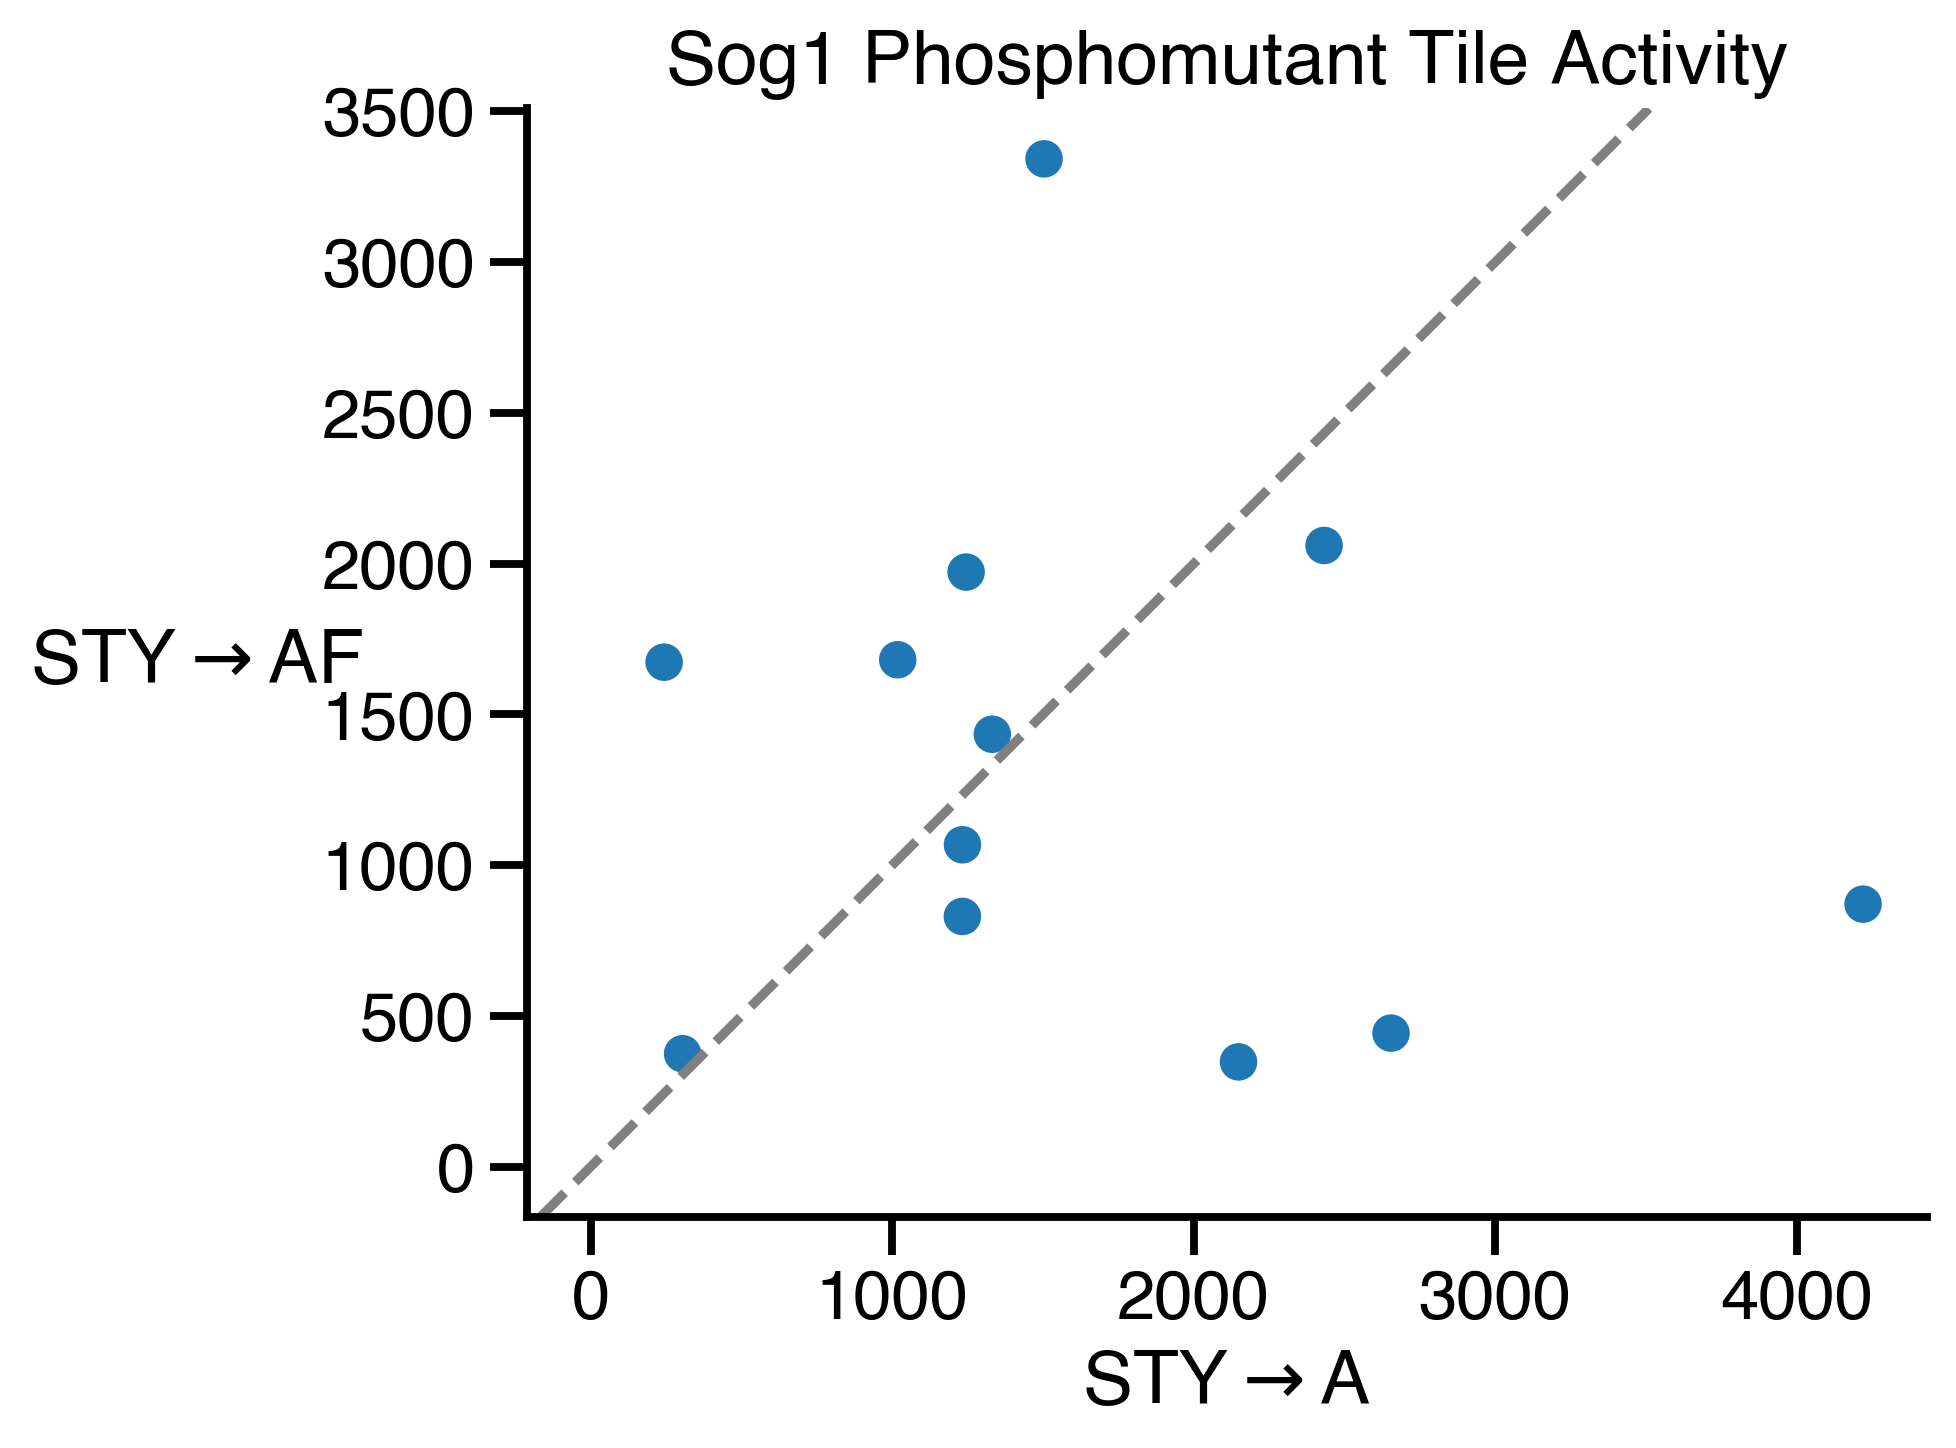

In [77]:
plt.figure(dpi = 300)
max_A_vs_F = pd.merge(PSv_max2A_STYA, PSv_max2A_STAYF, on = ["Start", "End", "mid"], suffixes = ("_A", "_AF")).dropna(subset = "Other")
sns.scatterplot(data = max_A_vs_F, x = activity_col + "_var", y = activity_col, edgecolor = 'none', alpha = 1)
plt.gca().set_aspect('equal')
plt.xlabel("STY$\\rightarrow$A")
plt.ylabel("STY$\\rightarrow$AF", rotation = 0, labelpad = 30, va = "center")
plt.title("Sog1 Phosphomutant Tile Activity")
plt.axline([0, 0], slope=1, color = "gray", linestyle = "--")
sns.despine()

## 5.2 Scatter plot of A1b vs A2b

In [78]:
PSv_pred2A_STYA = return_activities("PSv_pred2A_STYA")
PSv_pred2A_STYA.iloc[39]

Description                            40_PSv_pred2A_STYA
Other                                           PS:Y(!)x1
Start                                                 391
mid                                                   411
End                                                   431
tile             IADYAHLGPEDFKRDLEECQKIVLDPANIELDAPPEFRLA
Activity_S3_1                                         NaN
Activity_S3_2                                         NaN
lib2_avg                                              NaN
Name: 39, dtype: object

In [79]:
PSv_pred2A_STAYF = return_activities("PSv_pred2A_STAYF")
PSv_pred2A_STAYF.head(3)

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,1_PSv_pred2A_STAYF,NaN,1,21,41,MAGRSWLIDANRIAAKIMAAAAAADPRQVVWKANPARHCP,666.165245,480.501453,573.333349
1,2_PSv_pred2A_STAYF,NaN,11,31,51,NRIAAKIMAAAAAADPRQVVWKANPARHCPKCQHVIDNSD,457.515144,482.312290,469.913717
2,3_PSv_pred2A_STAYF,NaN,21,41,61,AAAADPRQVVWKANPARHCPKCQHVIDNSDVVDDWPGLPR,293.313833,315.897642,304.605737


In [80]:
pd.merge(PSv_pred2A_STYA,
                                PSv_pred2A_STAYF,
                                on = ["Start", "mid", "End"],
                               suffixes = ("_A", "_F"))

,Description_A,Other_A,Start,mid,End,tile_A,Activity_S3_1_A,Activity_S3_2_A,lib2_avg_A,Description_F,Other_F,tile_F,Activity_S3_1_F,Activity_S3_2_F,lib2_avg_F
0,1_PSv_pred2A_STYA,NaN,1,21,41,MAGRSWLIDANRIAAKIMAAAAAADPRQVVWKANPARHCP,666.165245,480.501453,573.333349,1_PSv_pred2A_STAYF,NaN,MAGRSWLIDANRIAAKIMAAAAAADPRQVVWKANPARHCP,666.165245,480.501453,573.333349
1,2_PSv_pred2A_STYA,NaN,11,31,51,NRIAAKIMAAAAAADPRQVVWKANPARHCPKCQHVIDNSD,457.515144,482.312290,469.913717,2_PSv_pred2A_STAYF,NaN,NRIAAKIMAAAAAADPRQVVWKANPARHCPKCQHVIDNSD,457.515144,482.312290,469.913717
2,3_PSv_pred2A_STYA,NaN,21,41,61,AAAADPRQVVWKANPARHCPKCQHVIDNSDVVDDWPGLPR,293.313833,315.897642,304.605737,3_PSv_pred2A_STAYF,NaN,AAAADPRQVVWKANPARHCPKCQHVIDNSDVVDDWPGLPR,293.313833,315.897642,304.605737
3,4_PSv_pred2A_STYA,NaN,31,51,71,WKANPARHCPKCQHVIDNSDVVDDWPGLPRGVKFDPADPE,1491.966850,1474.163284,1483.065067,4_PSv_pred2A_STAYF,NaN,WKANPARHCPKCQHVIDNSDVVDDWPGLPRGVKFDPADPE,1491.966850,1474.163284,1483.065067
4,5_PSv_pred2A_STYA,NaN,41,61,81,KCQHVIDNSDVVDDWPGLPRGVKFDPADPEIIWHLLAKSG,1321.816877,1086.251778,1204.034327,5_PSv_pred2A_STAYF,NaN,KCQHVIDNSDVVDDWPGLPRGVKFDPADPEIIWHLLAKSG,1321.816877,1086.251778,1204.034327
5,6_PSv_pred2A_STYA,NaN,51,71,91,VVDDWPGLPRGVKFDPADPEIIWHLLAKAGLAGLAAHPFI,3826.168080,3791.352028,3808.760054,6_PSv_pred2A_STAYF,NaN,VVDDWPGLPRGVKFDPADPEIIWHLLAKAGLAGLAAHPFI,3826.168080,3791.352028,3808.760054
6,7_PSv_pred2A_STYA,NaN,61,81,101,GVKFDPADPEIIWHLLAKAGLAGLAAHPFIDEFIPAVNQD,859.106155,775.375562,817.240859,7_PSv_pred2A_STAYF,NaN,GVKFDPADPEIIWHLLAKAGLAGLAAHPFIDEFIPAVNQD,859.106155,775.375562,817.240859
7,8_PSv_pred2A_STYA,PS:Y(!)x1,71,91,111,IIWHLLAKAGLAGLAAHPFIDEFIPAVNQDDGICYAHPKN,1481.559548,1531.480934,1506.520241,8_PSv_pred2A_STAYF,PS:Y(!)x1,IIWHLLAKAGLAGLAAHPFIDEFIPAVNQDDGICYAHPKN,1481.559548,1531.480934,1506.520241
8,9_PSv_pred2A_STYA,PS:Y(!)x1,81,101,121,LAGLAAHPFIDEFIPAVNQDDGICYAHPKNLPGVKADGTV,1632.723213,1239.331515,1436.027364,9_PSv_pred2A_STAYF,PS:Y(!)x1,LAGLAAHPFIDEFIPAVNQDDGICYAHPKNLPGVKADGTV,1632.723213,1239.331515,1436.027364
9,10_PSv_pred2A_STYA,PS:Y(!)x1,91,111,131,DEFIPAVNQDDGICYAHPKNLPGVKADGTVAHFFHKAIKA,2033.494081,2660.089843,2346.791962,10_PSv_pred2A_STAYF,PS:Y(!)x1,DEFIPAVNQDDGICYAHPKNLPGVKADGTVAHFFHKAIKA,2033.494081,2660.089843,2346.791962


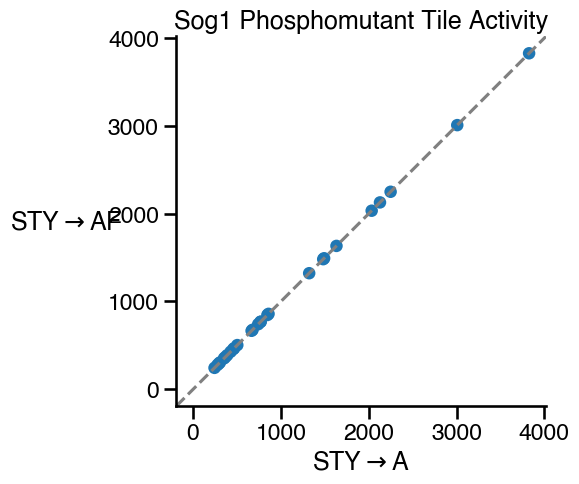

In [81]:
sns.scatterplot(data = pd.merge(PSv_pred2A_STYA,
                                PSv_pred2A_STAYF,
                                on = ["Start", "mid", "End"],
                               suffixes = ("_A", "_F")), 
                x = activity_col + "_A", y = activity_col + "_F", edgecolor = 'none', alpha = 1)
plt.gca().set_aspect('equal')
plt.xlabel("STY$\\rightarrow$A")
plt.ylabel("STY$\\rightarrow$AF", rotation = 0, labelpad = 30, va = "center")
plt.title("Sog1 Phosphomutant Tile Activity")
plt.axline([0, 0], slope=1, color = "gray", linestyle = "--")
sns.despine()
# Seems like there's a mistake with the library sequences? look identical to me...

# Full phosphomutant vs phosphomimetics

In [82]:
# Confirmed --> A|
PSv_conf2fA_STYA = return_activities("PSv_conf2fA_STYA")
PSv_conf2fA_STYA.head(3)

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,7_PSv_conf2fA_STYA,NaN,61,81,101,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,589.233964,567.661610,578.447787
1,8_PSv_conf2fA_STYA,NaN,71,91,111,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,2073.520699,2127.003654,2100.262176
2,9_PSv_conf2fA_STYA,NaN,81,101,121,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,1469.859938,1112.678850,1291.269394


In [83]:
# WT tiles
BasicArTh = return_activities("BasicArTh", pos_regex = r'\.(\d+)')
BasicArTh.head(3)

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,BasicArTh.1,Q6NQK2,1,21,41,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,1407.799127,1244.615820,1326.207474
1,BasicArTh.2,Q6NQK2,11,31,51,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4479.018364,3954.541874,4216.780119
2,BasicArTh.3,Q6NQK2,21,41,61,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,1434.266772,1013.665108,1223.965940


In [84]:
# confirmed -> D
PSv_conf2fD = return_activities("PSv_conf2fD")
PSv_conf2fD = PSv_conf2fD[~PSv_conf2fD["Description"].str.contains("DD")]
PSv_conf2fD.head(3)

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,7_PSv_conf2fD,/,61,81,101,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPDVNQD,612.310337,525.559638,568.934988
1,8_PSv_conf2fD,/,71,91,111,IIWHLLAKSGLSGLSSHPFIDEFIPDVNQDDGICYTHPKN,1330.105073,964.886411,1147.495742
2,9_PSv_conf2fD,/,81,101,121,LSGLSSHPFIDEFIPDVNQDDGICYTHPKNLPGVKSDGTV,3366.486424,3734.635082,3550.560753


In [85]:
# confirmed -> E
PSv_conf2fE = return_activities("PSv_conf2fE")
PSv_conf2fE = PSv_conf2fE[~PSv_conf2fE["Description"].str.contains("EE")]
PSv_conf2fE.head(3)

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,7_PSv_conf2fE,/,61,81,101,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPEVNQD,1196.413506,1294.538370,1245.475938
1,8_PSv_conf2fE,/,71,91,111,IIWHLLAKSGLSGLSSHPFIDEFIPEVNQDDGICYTHPKN,333.031253,320.143346,326.587300
2,9_PSv_conf2fE,/,81,101,121,LSGLSSHPFIDEFIPEVNQDDGICYTHPKNLPGVKSDGTV,5679.765438,1525.343149,3602.554294


In [86]:
sns.color_palette('Dark2')

[(0.10588235294117647, 0.6196078431372549, 0.4666666666666667),
 (0.8509803921568627, 0.37254901960784315, 0.00784313725490196),
 (0.4588235294117647, 0.4392156862745098, 0.7019607843137254),
 (0.9058823529411765, 0.1607843137254902, 0.5411764705882353),
 (0.4, 0.6509803921568628, 0.11764705882352941),
 (0.9019607843137255, 0.6705882352941176, 0.00784313725490196),
 (0.6509803921568628, 0.4627450980392157, 0.11372549019607843),
 (0.4, 0.4, 0.4)]

In [87]:
BasicArTh

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,BasicArTh.1,Q6NQK2,1,21,41,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,1407.799127,1244.615820,1326.207474
1,BasicArTh.2,Q6NQK2,11,31,51,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4479.018364,3954.541874,4216.780119
2,BasicArTh.3,Q6NQK2,21,41,61,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,1434.266772,1013.665108,1223.965940
3,BasicArTh.4,Q6NQK2,31,51,71,WKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPE,3815.896461,3782.725600,3799.311031
4,BasicArTh.5,Q6NQK2,41,61,81,KCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSG,538.931880,933.900949,736.416415
5,BasicArTh.6,Q6NQK2,51,71,91,VVDDWPGLPRGVKFDPSDPEIIWHLLAKSGLSGLSSHPFI,1379.276161,1392.248129,1385.762145
6,BasicArTh.7,Q6NQK2,61,81,101,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQD,640.499185,1517.695164,1079.097175
7,BasicArTh.8,Q6NQK2,71,91,111,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,444.761592,369.638636,407.200114
8,BasicArTh.9,Q6NQK2,81,101,121,LSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTV,3635.249963,1403.352788,2519.301376
9,BasicArTh.10,Q6NQK2,91,111,131,DEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,1974.901465,1577.686428,1776.293946


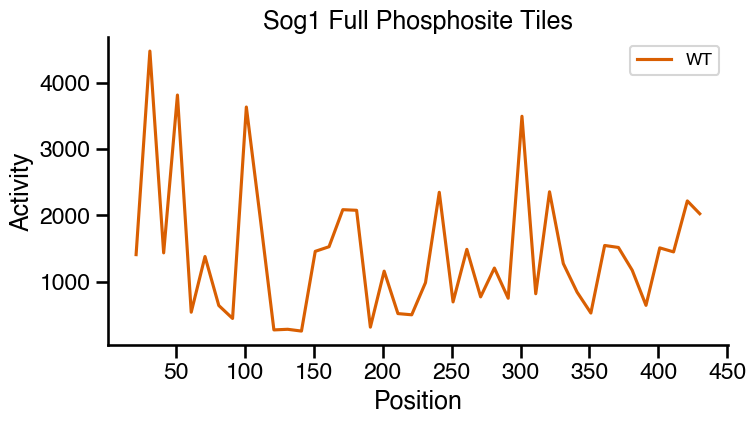

In [88]:
plt.figure(figsize = (8, 4))
plt.title("Sog1 Full Phosphosite Tiles")
# sns.lineplot(data = PSv_conf2fD, x = "mid", y = "Activity_S3_1", label = "Phosphomimetic (→ D)", 
#              color = sns.color_palette('Dark2')[0])
# sns.lineplot(data = PSv_conf2fE, x = "mid", y = "Activity_S3_1", label = "Phosphomimetic (→ E)", 
#              color = sns.color_palette('Dark2')[4])
# sns.lineplot(data = PSv_conf2fA_STYA, x = "mid", y = "Activity_S3_1", label = "Phosphomutant (→ A)",
#             color = sns.color_palette('Dark2')[2])
sns.lineplot(data = BasicArTh, x = "mid", y = "Activity_S3_1", label = "WT",
            color = sns.color_palette('Dark2')[1])
plt.ylabel("Activity")
plt.xlabel("Position")
plt.legend(fontsize = 'x-small')
sns.despine()

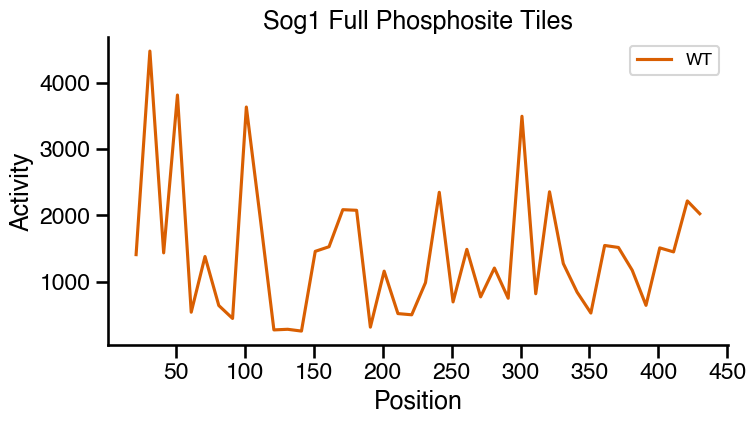

In [89]:
plt.figure(figsize = (8, 4))
plt.title("Sog1 Full Phosphosite Tiles")
# sns.lineplot(data = PSv_conf2fD, x = "mid", y = "Activity_S3_1", label = "Phosphomimetic (→ D)", 
#              color = sns.color_palette('Dark2')[0])
# sns.lineplot(data = PSv_conf2fE, x = "mid", y = "Activity_S3_1", label = "Phosphomimetic (→ E)", 
#              color = sns.color_palette('Dark2')[4])
# sns.lineplot(data = PSv_conf2fA_STYA, x = "mid", y = "Activity_S3_1", label = "Phosphomutant (→ A)",
#             color = sns.color_palette('Dark2')[2])
sns.lineplot(data = BasicArTh, x = "mid", y = "Activity_S3_1", label = "WT",
            color = sns.color_palette('Dark2')[1])
plt.ylabel("Activity")
plt.xlabel("Position")
plt.legend(fontsize = 'x-small')
sns.despine()

# Single confirmed phosphomutants

In [90]:
# Confirmed --> A|
PSv_conf2sA_STYA = return_activities("PSv_conf2sA_STYA")
PSv_conf2sA_STYA.head(3)

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,7_PSv_conf2sA_STYA,NaN,61,81,101,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,589.233964,567.661610,578.447787
1,8_PSv_conf2sA_STYA,NaN,71,91,111,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,2073.520699,2127.003654,2100.262176
2,9_PSv_conf2sA_STYA,NaN,81,101,121,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,1469.859938,1112.678850,1291.269394


In [91]:
BasicArTh

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,BasicArTh.1,Q6NQK2,1,21,41,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,1407.799127,1244.615820,1326.207474
1,BasicArTh.2,Q6NQK2,11,31,51,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4479.018364,3954.541874,4216.780119
2,BasicArTh.3,Q6NQK2,21,41,61,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,1434.266772,1013.665108,1223.965940
3,BasicArTh.4,Q6NQK2,31,51,71,WKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPE,3815.896461,3782.725600,3799.311031
4,BasicArTh.5,Q6NQK2,41,61,81,KCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSG,538.931880,933.900949,736.416415
5,BasicArTh.6,Q6NQK2,51,71,91,VVDDWPGLPRGVKFDPSDPEIIWHLLAKSGLSGLSSHPFI,1379.276161,1392.248129,1385.762145
6,BasicArTh.7,Q6NQK2,61,81,101,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQD,640.499185,1517.695164,1079.097175
7,BasicArTh.8,Q6NQK2,71,91,111,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,444.761592,369.638636,407.200114
8,BasicArTh.9,Q6NQK2,81,101,121,LSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTV,3635.249963,1403.352788,2519.301376
9,BasicArTh.10,Q6NQK2,91,111,131,DEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,1974.901465,1577.686428,1776.293946


In [92]:
conf2sA_STYA_vs_basic = pd.merge(PSv_conf2sA_STYA, BasicArTh, on = "mid", suffixes = ("_var", "_wt"), how = "right")
conf2sA_STYA_vs_basic

,Description_var,Other_var,Start_var,mid,End_var,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,Description_wt,Other_wt,Start_wt,End_wt,tile_wt,Activity_S3_1_wt,Activity_S3_2_wt,lib2_avg_wt
0,NaN,NaN,NaN,21,NaN,NaN,NaN,NaN,NaN,BasicArTh.1,Q6NQK2,1,41,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,1407.799127,1244.615820,1326.207474
1,NaN,NaN,NaN,31,NaN,NaN,NaN,NaN,NaN,BasicArTh.2,Q6NQK2,11,51,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4479.018364,3954.541874,4216.780119
2,NaN,NaN,NaN,41,NaN,NaN,NaN,NaN,NaN,BasicArTh.3,Q6NQK2,21,61,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,1434.266772,1013.665108,1223.965940
3,NaN,NaN,NaN,51,NaN,NaN,NaN,NaN,NaN,BasicArTh.4,Q6NQK2,31,71,WKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPE,3815.896461,3782.725600,3799.311031
4,NaN,NaN,NaN,61,NaN,NaN,NaN,NaN,NaN,BasicArTh.5,Q6NQK2,41,81,KCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSG,538.931880,933.900949,736.416415
5,NaN,NaN,NaN,71,NaN,NaN,NaN,NaN,NaN,BasicArTh.6,Q6NQK2,51,91,VVDDWPGLPRGVKFDPSDPEIIWHLLAKSGLSGLSSHPFI,1379.276161,1392.248129,1385.762145
6,7_PSv_conf2sA_STYA,NaN,61.0,81,101.0,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,589.233964,567.661610,578.447787,BasicArTh.7,Q6NQK2,61,101,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQD,640.499185,1517.695164,1079.097175
7,8_PSv_conf2sA_STYA,NaN,71.0,91,111.0,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,2073.520699,2127.003654,2100.262176,BasicArTh.8,Q6NQK2,71,111,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,444.761592,369.638636,407.200114
8,9_PSv_conf2sA_STYA,NaN,81.0,101,121.0,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,1469.859938,1112.678850,1291.269394,BasicArTh.9,Q6NQK2,81,121,LSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTV,3635.249963,1403.352788,2519.301376
9,10_PSv_conf2sA_STYA,NaN,91.0,111,131.0,DEFIPAVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,2016.437518,1159.883146,1588.160332,BasicArTh.10,Q6NQK2,91,131,DEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,1974.901465,1577.686428,1776.293946


In [93]:


# Apply this function to each row in the DataFrame
diffs = []
for i in conf2sA_STYA_vs_basic.index:
    diffs.append(find_difference_index(conf2sA_STYA_vs_basic['tile_var'].iloc[i], 
                                       conf2sA_STYA_vs_basic['tile_wt'].iloc[i]))
conf2sA_STYA_vs_basic["var"] = diffs
conf2sA_STYA_vs_basic["var"] = conf2sA_STYA_vs_basic["var"] + conf2sA_STYA_vs_basic["Start_var"]
conf2sA_STYA_vs_basic["activ_change"] = conf2sA_STYA_vs_basic["Activity_S3_1_var"] - conf2sA_STYA_vs_basic["Activity_S3_1_wt"]
conf2sA_STYA_vs_basic

,Description_var,Other_var,Start_var,mid,End_var,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,Description_wt,Other_wt,Start_wt,End_wt,tile_wt,Activity_S3_1_wt,Activity_S3_2_wt,lib2_avg_wt,var,activ_change
0,NaN,NaN,NaN,21,NaN,NaN,NaN,NaN,NaN,BasicArTh.1,Q6NQK2,1,41,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,1407.799127,1244.615820,1326.207474,NaN,NaN
1,NaN,NaN,NaN,31,NaN,NaN,NaN,NaN,NaN,BasicArTh.2,Q6NQK2,11,51,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4479.018364,3954.541874,4216.780119,NaN,NaN
2,NaN,NaN,NaN,41,NaN,NaN,NaN,NaN,NaN,BasicArTh.3,Q6NQK2,21,61,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,1434.266772,1013.665108,1223.965940,NaN,NaN
3,NaN,NaN,NaN,51,NaN,NaN,NaN,NaN,NaN,BasicArTh.4,Q6NQK2,31,71,WKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPE,3815.896461,3782.725600,3799.311031,NaN,NaN
4,NaN,NaN,NaN,61,NaN,NaN,NaN,NaN,NaN,BasicArTh.5,Q6NQK2,41,81,KCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSG,538.931880,933.900949,736.416415,NaN,NaN
5,NaN,NaN,NaN,71,NaN,NaN,NaN,NaN,NaN,BasicArTh.6,Q6NQK2,51,91,VVDDWPGLPRGVKFDPSDPEIIWHLLAKSGLSGLSSHPFI,1379.276161,1392.248129,1385.762145,NaN,NaN
6,7_PSv_conf2sA_STYA,NaN,61.0,81,101.0,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,589.233964,567.661610,578.447787,BasicArTh.7,Q6NQK2,61,101,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQD,640.499185,1517.695164,1079.097175,96.0,-51.265221
7,8_PSv_conf2sA_STYA,NaN,71.0,91,111.0,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,2073.520699,2127.003654,2100.262176,BasicArTh.8,Q6NQK2,71,111,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,444.761592,369.638636,407.200114,96.0,1628.759107
8,9_PSv_conf2sA_STYA,NaN,81.0,101,121.0,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,1469.859938,1112.678850,1291.269394,BasicArTh.9,Q6NQK2,81,121,LSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTV,3635.249963,1403.352788,2519.301376,96.0,-2165.390025
9,10_PSv_conf2sA_STYA,NaN,91.0,111,131.0,DEFIPAVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,2016.437518,1159.883146,1588.160332,BasicArTh.10,Q6NQK2,91,131,DEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,1974.901465,1577.686428,1776.293946,96.0,41.536053


In [94]:
set(conf2sA_STYA_vs_basic["var"])

{nan,
 nan,
 nan,
 nan,
 nan,
 423.0,
 nan,
 nan,
 430.0,
 nan,
 436.0,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 249.0,
 350.0,
 nan,
 96.0,
 nan,
 356.0,
 nan,
 237.0,
 nan,
 nan,
 244.0,
 nan,
 372.0}

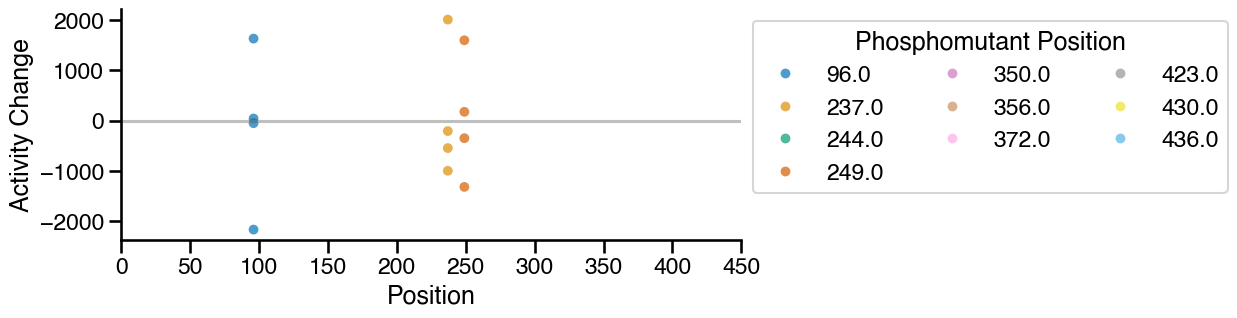

In [95]:
plt.figure(figsize = (8, 3))
plt.axhline(0, color = "gray", alpha = 0.5)
sns.scatterplot(data = conf2sA_STYA_vs_basic, x = "var", y = "activ_change", 
                edgecolor = 'none', alpha = 0.7, s = 50, hue = "var", 
                palette = "colorblind")
plt.legend(bbox_to_anchor = (1, 1), title = "Phosphomutant Position", ncol = 3)
plt.xlabel("Position")
plt.ylabel("Activity Change")
plt.xlim(0, 450)
sns.despine()

In [96]:
# plt.figure(figsize = (8, 3))
# sns.lineplot(data = conf2sA_STYA_vs_basic, x = "mid", y = "Activity_S3_1_wt")
# sns.scatterplot(data = conf2sA_STYA_vs_basic, x = "mid", y = "Activity_S3_1_wt", s = 25)
# sns.scatterplot(data = conf2sA_STYA_vs_basic, x = "var", y = "Activity_S3_1_var", 
#                 edgecolor = 'none', alpha = 0.7, s = 50, hue = "var", palette = 'colorblind', legend = False)
# #plt.legend(bbox_to_anchor = (1, 1), title = "Phosphomutant Position", ncol = 3)
# plt.xlabel("Position")
# plt.ylabel("Activity")
# plt.title("Single Confirmed Phosphomutant Effect")
# sns.despine()

In [97]:
basic_conf_A_D = pd.merge(conf2sA_STYA_vs_basic, PSv_conf2fD, on = "mid", how = "left")
basic_conf_A_D

,Description_var,Other_var,Start_var,mid,End_var,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,Description_wt,...,var,activ_change,Description,Other,Start,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,NaN,NaN,NaN,21,NaN,NaN,NaN,NaN,NaN,BasicArTh.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,31,NaN,NaN,NaN,NaN,NaN,BasicArTh.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,41,NaN,NaN,NaN,NaN,NaN,BasicArTh.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,51,NaN,NaN,NaN,NaN,NaN,BasicArTh.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,61,NaN,NaN,NaN,NaN,NaN,BasicArTh.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,71,NaN,NaN,NaN,NaN,NaN,BasicArTh.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7_PSv_conf2sA_STYA,NaN,61.0,81,101.0,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,589.233964,567.661610,578.447787,BasicArTh.7,...,96.0,-51.265221,7_PSv_conf2fD,/,61.0,101.0,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPDVNQD,612.310337,525.559638,568.934988
7,8_PSv_conf2sA_STYA,NaN,71.0,91,111.0,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,2073.520699,2127.003654,2100.262176,BasicArTh.8,...,96.0,1628.759107,8_PSv_conf2fD,/,71.0,111.0,IIWHLLAKSGLSGLSSHPFIDEFIPDVNQDDGICYTHPKN,1330.105073,964.886411,1147.495742
8,9_PSv_conf2sA_STYA,NaN,81.0,101,121.0,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,1469.859938,1112.678850,1291.269394,BasicArTh.9,...,96.0,-2165.390025,9_PSv_conf2fD,/,81.0,121.0,LSGLSSHPFIDEFIPDVNQDDGICYTHPKNLPGVKSDGTV,3366.486424,3734.635082,3550.560753
9,10_PSv_conf2sA_STYA,NaN,91.0,111,131.0,DEFIPAVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,2016.437518,1159.883146,1588.160332,BasicArTh.10,...,96.0,41.536053,10_PSv_conf2fD,/,91.0,131.0,DEFIPDVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,1617.016395,1028.150576,1322.583486


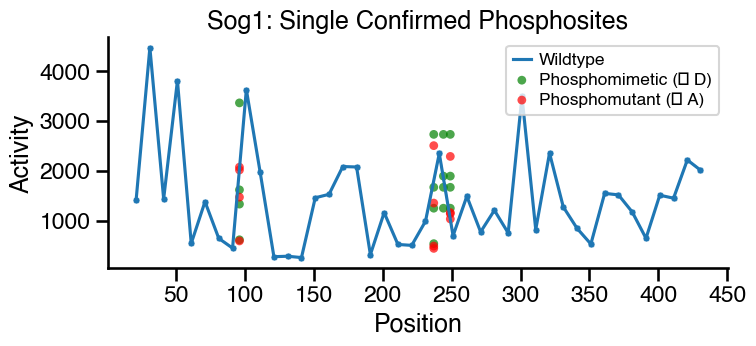

In [98]:
plt.figure(figsize = (8, 3))
sns.lineplot(data = conf2sA_STYA_vs_basic, x = "mid", y = "Activity_S3_1_wt", label = "Wildtype")
sns.scatterplot(data = conf2sA_STYA_vs_basic, x = "mid", y = "Activity_S3_1_wt", s = 25)
sns.scatterplot(data = basic_conf_A_D, x = "var", y = "Activity_S3_1", color = "green",
               alpha = 0.7, s = 40, label = "Phosphomimetic (→ D)", edgecolor = 'none')
sns.scatterplot(data = conf2sA_STYA_vs_basic, x = "var", y = "Activity_S3_1_var", color = "red",
               alpha = 0.7, s = 40, label = "Phosphomutant (→ A)", edgecolor = 'none')


plt.legend(fontsize = 'x-small', handletextpad = 0.5, handlelength = 1, labelspacing = 0.25)
plt.xlabel("Position")
plt.ylabel("Activity")
plt.title("Sog1: Single Confirmed Phosphosites")
sns.despine()

In [248]:
len(activities)

10309

In [ ]:
plt.figure(figsize = (8, 4))
plt.title("Sog1 Full Phosphosite Tiles")
sns.lineplot(data = PSv_conf2fA_STYA, x = "mid", y = "Activity_S3_1", label = "Phosphomutant (→ A)",
            color = sns.color_palette('Dark2')[2])


plt.ylabel("Activity")
plt.xlabel("Position")
plt.legend(fontsize = 'x-small')
sns.despine()

In [90]:
library["Description"] = library["Description"].astype(str)

In [104]:
library["Description"].value_counts().head(10)

Description
32_CHA_DEtoA_duos         105
32_CHA_dead_AtoDE_duos    105
33_CHA_DEtoA_duos          78
33_CHA_dead_AtoDE_duos     78
34_CHA_DEtoA_duos          49
34_CHA_dead_AtoDE_duos     49
8_Ascan_comb               46
8_Dscan_comb               46
8_Kscan_comb               46
8_Pscan_comb               46
Name: count, dtype: int64

In [114]:
library[library["Description"].str.contains("PSv_max2A_STYA")]

,ProteinSeq,Description,Other
13170,MAGRAWLIDANRIAAKIMAAAAAADPRQVVWKANPARHCP,1_PSv_max2A_STYA,NaN
13171,NRIAAKIMAAAAAADPRQVVWKANPARHCPKCQHVIDNAD,2_PSv_max2A_STYA,NaN
13172,AAAADPRQVVWKANPARHCPKCQHVIDNADVVDDWPGLPR,3_PSv_max2A_STYA,NaN
13173,WKANPARHCPKCQHVIDNADVVDDWPGLPRGVKFDPADPE,4_PSv_max2A_STYA,NaN
13174,KCQHVIDNADVVDDWPGLPRGVKFDPADPEIIWHLLAKSG,5_PSv_max2A_STYA,NaN
13175,VVDDWPGLPRGVKFDPADPEIIWHLLAKAGLAGLAAHPFI,6_PSv_max2A_STYA,NaN
13176,GVKFDPADPEIIWHLLAKAGLAGLAAHPFIDEFIPAVNQD,7_PSv_max2A_STYA,NaN
13177,IIWHLLAKAGLAGLAAHPFIDEFIPAVNQDDGICAAHPKN,8_PSv_max2A_STYA,PS:Y(!)x1
13178,LAGLAAHPFIDEFIPAVNQDDGICAAHPKNLPGVKADGAV,9_PSv_max2A_STYA,PS:Y(!)x1
13179,DEFIPAVNQDDGICAAHPKNLPGVKADGAVAHFFHKAIKA,10_PSv_max2A_STYA,PS:Y(!)x1


In [110]:
library[library["Description"].str.contains("PSv_max2A_STAYF")]

,ProteinSeq,Description,Other
13346,MAGRAWLIDANRIAAKIMAAAAAADPRQVVWKANPARHCP,1_PSv_max2A_STAYF,NaN
13347,NRIAAKIMAAAAAADPRQVVWKANPARHCPKCQHVIDNAD,2_PSv_max2A_STAYF,NaN
13348,AAAADPRQVVWKANPARHCPKCQHVIDNADVVDDWPGLPR,3_PSv_max2A_STAYF,NaN
13349,WKANPARHCPKCQHVIDNADVVDDWPGLPRGVKFDPADPE,4_PSv_max2A_STAYF,NaN
13350,KCQHVIDNADVVDDWPGLPRGVKFDPADPEIIWHLLAKSG,5_PSv_max2A_STAYF,NaN
13351,VVDDWPGLPRGVKFDPADPEIIWHLLAKAGLAGLAAHPFI,6_PSv_max2A_STAYF,NaN
13352,GVKFDPADPEIIWHLLAKAGLAGLAAHPFIDEFIPAVNQD,7_PSv_max2A_STAYF,NaN
13353,IIWHLLAKAGLAGLAAHPFIDEFIPAVNQDDGICFAHPKN,8_PSv_max2A_STAYF,PS:Y(!)x1
13354,LAGLAAHPFIDEFIPAVNQDDGICFAHPKNLPGVKADGAV,9_PSv_max2A_STAYF,PS:Y(!)x1
13355,DEFIPAVNQDDGICFAHPKNLPGVKADGAVAHFFHKAIKA,10_PSv_max2A_STAYF,PS:Y(!)x1


In [94]:
library[library["Description"].str.contains("PSv_pred2A_STYA")]

,ProteinSeq,Description,Other
13212,MAGRSWLIDANRIAAKIMAAAAAADPRQVVWKANPARHCP,1_PSv_pred2A_STYA,NaN
13213,NRIAAKIMAAAAAADPRQVVWKANPARHCPKCQHVIDNSD,2_PSv_pred2A_STYA,NaN
13214,AAAADPRQVVWKANPARHCPKCQHVIDNSDVVDDWPGLPR,3_PSv_pred2A_STYA,NaN
13215,WKANPARHCPKCQHVIDNSDVVDDWPGLPRGVKFDPADPE,4_PSv_pred2A_STYA,NaN
13216,KCQHVIDNSDVVDDWPGLPRGVKFDPADPEIIWHLLAKSG,5_PSv_pred2A_STYA,NaN
13217,VVDDWPGLPRGVKFDPADPEIIWHLLAKAGLAGLAAHPFI,6_PSv_pred2A_STYA,NaN
13218,GVKFDPADPEIIWHLLAKAGLAGLAAHPFIDEFIPAVNQD,7_PSv_pred2A_STYA,NaN
13219,IIWHLLAKAGLAGLAAHPFIDEFIPAVNQDDGICYAHPKN,8_PSv_pred2A_STYA,PS:Y(!)x1
13220,LAGLAAHPFIDEFIPAVNQDDGICYAHPKNLPGVKADGTV,9_PSv_pred2A_STYA,PS:Y(!)x1
13221,DEFIPAVNQDDGICYAHPKNLPGVKADGTVAHFFHKAIKA,10_PSv_pred2A_STYA,PS:Y(!)x1


In [96]:
library[library["Description"].str.contains("PSv_conf2sA_STYA")]

,ProteinSeq,Description,Other
13254,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,7_PSv_conf2sA_STYA,NaN
13255,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,8_PSv_conf2sA_STYA,NaN
13256,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,9_PSv_conf2sA_STYA,NaN
13257,DEFIPAVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,10_PSv_conf2sA_STYA,NaN
13258,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVAPTA,21_PSv_conf2sA_STYA,NaN
13259,QQPQQLVVKRGDKAEQEVSEDIFAAVAPTADPVTPKLATP,22_PSv_conf2sA_STYA,NaN
13260,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVAPKLATP,22_PSv_conf2sA_STYA,NaN
13261,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLAAP,22_PSv_conf2sA_STYA,NaN
13262,GDKAEQEVSEDIFAAVAPTADPVTPKLATPEPRNAVRICS,23_PSv_conf2sA_STYA,NaN
13263,GDKAEQEVSEDIFAAVTPTADPVAPKLATPEPRNAVRICS,23_PSv_conf2sA_STYA,NaN


In [67]:
def return_activities(filepath):
    return_tiles = pd.read_csv(filepath, sep = "\t")
    
    return_tiles = return_tiles.rename(columns = {"AA sequence" : "tile"})
    return_tiles["Start"] = return_tiles["AA interval"].str.split("-").str[0].astype(int)
    return_tiles["End"] = return_tiles["AA interval"].str.split("-").str[1].astype(int)
    return_tiles["mid"] = (return_tiles["Start"] + return_tiles["End"]) / 2
    return_tiles["tile"] = return_tiles["tile"].astype(str).str.strip()
    
    activities = pd.read_csv("../data/Sog1_library2_activities_with_reads.csv")
    activities = activities.rename(columns = {"AAseq" : "tile"})
    activities["tile"] = activities["tile"].astype(str).str.strip()

    return pd.merge(return_tiles, activities[["tile", "Activity_S3_1"]], on = "tile")

In [68]:
wt_activ = return_activities("../data/wt_tiles.csv")
wt_activ

,Tile ID,AA interval,Length,SOG1 partim,tile,Remarks,Start,End,mid,Activity_S3_1
0,1,1-40,40,NTD,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,/,1,40,20.5,349.798825
1,2,11-50,40,NTD,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,/,11,50,30.5,470.700956
2,3,21-60,40,NTD + NAC,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,/,21,60,40.5,867.654700
3,4,31-70,40,NTD + NAC,WKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPE,/,31,70,50.5,594.934332
4,5,41-80,40,NTD + NAC,KCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSG,/,41,80,60.5,667.974526
5,6,51-90,40,NTD + NAC,VVDDWPGLPRGVKFDPSDPEIIWHLLAKSGLSGLSSHPFI,/,51,90,70.5,1548.153317
6,7,61-100,40,NAC,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQD,/,61,100,80.5,1195.592810
7,8,71-110,40,NAC,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,/,71,110,90.5,553.464718
8,9,81-120,40,NAC,LSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTV,/,81,120,100.5,733.541576
9,10,91-130,40,NAC,DEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,/,91,130,110.5,495.092751


In [69]:
max_A_phosphomut = return_activities("../data/maximal_A_phosphomutant.tsv")
max_A_phosphomut

,Tile ID,AA interval,Length,SOG1 partim,Description,tile,Remarks,Start,End,mid,Activity_S3_1
0,NaN,1-40,40,NTD,1_PSv_maxA_STYA,MAGRAWLIDANRIAAKIMAAAAAADPRQVVWKANPARHCP,NaN,1,40,20.5,2221.077253
1,NaN,11-50,40,NTD,2_PSv_maxA_STYA,NRIAAKIMAAAAAADPRQVVWKANPARHCPKCQHVIDNAD,NaN,11,50,30.5,571.070293
2,NaN,21-60,40,NTD + NAC,3_PSv_maxA_STYA,AAAADPRQVVWKANPARHCPKCQHVIDNADVVDDWPGLPR,NaN,21,60,40.5,767.843899
3,NaN,31-70,40,NTD + NAC,4_PSv_maxA_STYA,WKANPARHCPKCQHVIDNADVVDDWPGLPRGVKFDPADPE,NaN,31,70,50.5,325.410474
4,NaN,41-80,40,NTD + NAC,5_PSv_maxA_STYA,KCQHVIDNADVVDDWPGLPRGVKFDPADPEIIWHLLAKSG,NaN,41,80,60.5,564.295027
5,NaN,51-90,40,NTD + NAC,6_PSv_maxA_STYA,VVDDWPGLPRGVKFDPADPEIIWHLLAKAGLAGLAAHPFI,NaN,51,90,70.5,2777.904051
6,NaN,61-100,40,NAC,7_PSv_maxA_STYA,GVKFDPADPEIIWHLLAKAGLAGLAAHPFIDEFIPAVNQD,NaN,61,100,80.5,1278.976936
7,NaN,71-110,40,NAC,8_PSv_maxA_STYA,IIWHLLAKAGLAGLAAHPFIDEFIPAVNQDDGICAAHPKN,PS:Y(!)x1,71,110,90.5,2351.808451
8,NaN,81-120,40,NAC,9_PSv_maxA_STYA,LAGLAAHPFIDEFIPAVNQDDGICAAHPKNLPGVKADGAV,PS:Y(!)x1,81,120,100.5,1174.051945
9,NaN,91-130,40,NAC,10_PSv_maxA_STYA,DEFIPAVNQDDGICAAHPKNLPGVKADGAVAHFFHKAIKA,PS:Y(!)x1,91,130,110.5,4167.296694


In [70]:
full_A_phosphomut = return_activities("../data/full_A_phosphomutant.tsv")
full_A_phosphomut

,Tile ID,AA interval,Length,SOG1 partim,Description,tile,Remarks,Start,End,mid,Activity_S3_1
0,NaN,1-40,40,NTD,1_PSv_predA_STYA,MAGRSWLIDANRIAAKIMAAAAAADPRQVVWKANPARHCP,NaN,1,40,20.5,280.882059
1,NaN,11-50,40,NTD,2_PSv_predA_STYA,NRIAAKIMAAAAAADPRQVVWKANPARHCPKCQHVIDNSD,NaN,11,50,30.5,316.923054
2,NaN,21-60,40,NTD + NAC,3_PSv_predA_STYA,AAAADPRQVVWKANPARHCPKCQHVIDNSDVVDDWPGLPR,NaN,21,60,40.5,297.992003
3,NaN,31-70,40,NTD + NAC,4_PSv_predA_STYA,WKANPARHCPKCQHVIDNSDVVDDWPGLPRGVKFDPADPE,NaN,31,70,50.5,402.366669
4,NaN,41-80,40,NTD + NAC,5_PSv_predA_STYA,KCQHVIDNSDVVDDWPGLPRGVKFDPADPEIIWHLLAKSG,NaN,41,80,60.5,320.632032
5,NaN,51-90,40,NTD + NAC,6_PSv_predA_STYA,VVDDWPGLPRGVKFDPADPEIIWHLLAKAGLAGLAAHPFI,NaN,51,90,70.5,2777.904051
6,NaN,61-100,40,NAC,7_PSv_predA_STYA,GVKFDPADPEIIWHLLAKAGLAGLAAHPFIDEFIPAVNQD,NaN,61,100,80.5,1278.976936
7,NaN,71-110,40,NAC,8_PSv_predA_STYA,IIWHLLAKAGLAGLAAHPFIDEFIPAVNQDDGICYAHPKN,PS:Y(!)x1,71,110,90.5,2365.051074
8,NaN,81-120,40,NAC,9_PSv_predA_STYA,LAGLAAHPFIDEFIPAVNQDDGICYAHPKNLPGVKADGTV,PS:Y(!)x1,81,120,100.5,610.609357
9,NaN,91-130,40,NAC,10_PSv_predA_STYA,DEFIPAVNQDDGICYAHPKNLPGVKADGTVAHFFHKAIKA,PS:Y(!)x1,91,130,110.5,618.169787


In [71]:
confirmed_A_phosphomut = return_activities("../data/confirmed_A_phosphomutant.tsv")
confirmed_A_phosphomut

,Tile ID,AA interval,Length,SOG1 partim,Description,tile,Remarks,Start,End,mid,Activity_S3_1
0,NaN,61-100,40,NAC,7_PSv_confsA_STYA,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,NaN,61,100,80.5,938.283433
1,NaN,71-110,40,NAC,8_PSv_confsA_STYA,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,NaN,71,110,90.5,NaN
2,NaN,81-120,40,NAC,9_PSv_confsA_STYA,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,NaN,81,120,100.5,1858.333362
3,NaN,91-130,40,NAC,10_PSv_confsA_STYA,DEFIPAVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,NaN,91,130,110.5,NaN
4,NaN,201-240,40,NAC + CTD,21_PSv_confsA_STYA,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVAPTA,NaN,201,240,220.5,2760.512552
5,NaN,211-250,40,NAC + CTD,22_PSv_confsA_STYA,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVAPKLATP,NaN,211,250,230.5,463.613666
6,NaN,211-250,40,NAC + CTD,22_PSv_confsA_STYA,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLAAP,NaN,211,250,230.5,923.329508
7,NaN,221-260,40,CTD,23_PSv_confsA_STYA,GDKAEQEVSEDIFAAVTPTADPVAPKLATPEPRNAVRICS,NaN,221,260,240.5,496.086024
8,NaN,221-260,40,CTD,23_PSv_confsA_STYA,GDKAEQEVSEDIFAAVTPTADPVTPKLAAPEPRNAVRICS,NaN,221,260,240.5,804.327385
9,NaN,231-270,40,CTD,24_PSv_confsA_STYA,DIFAAVAPTADPVTPKLATPEPRNAVRICSDSHIASDYVT,NaN,231,270,250.5,484.727505


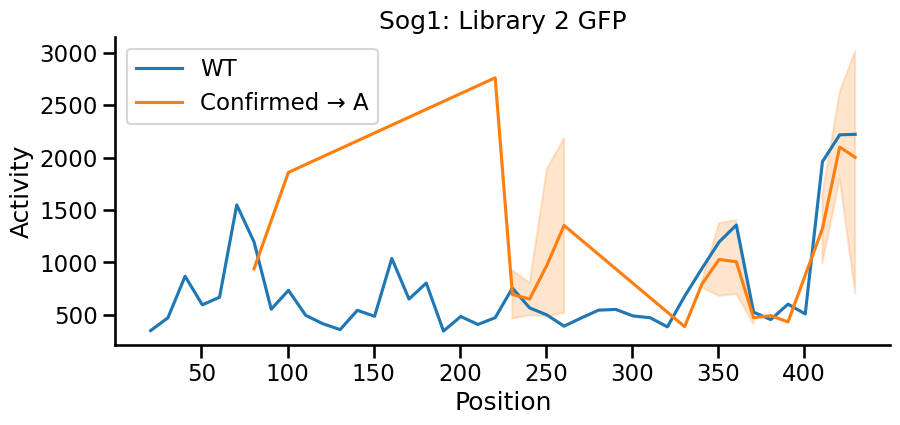

In [111]:
plt.figure(figsize = (10, 4))
sns.set_context('talk')
sns.lineplot(data = wt_activ, x= "mid", y = "Activity_S3_1", label = "WT")
#sns.lineplot(data = max_A_phosphomut, x= "mid", y = "Activity_S3_1", label = "STY → A")
#sns.lineplot(data = full_A_phosphomut, x= "mid", y = "Activity_S3_1", label = "Confirmed + Predicted → A")
sns.lineplot(data = confirmed_A_phosphomut, x= "mid", y = "Activity_S3_1", label = "Confirmed → A")
plt.xlabel("Position")
#plt.ylim(0,  8000)
plt.ylabel("Activity")
plt.title("Sog1: Library 2 GFP")
sns.despine()

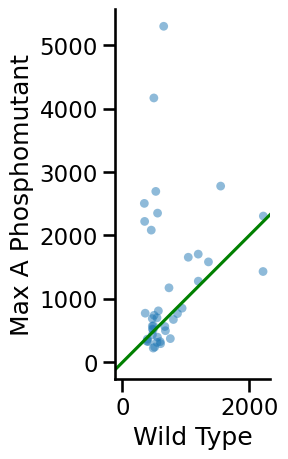

In [30]:
sns.set_context('talk')

merged = pd.merge(wt_activ[["Start", "End", "Activity_S3_1"]], max_A_phosphomut[["Start", "End", "Activity_S3_1"]], on = ["Start", "End"])
plt.gca().set_aspect('equal')
sns.scatterplot(data = merged, x = "Activity_S3_1_x", y = "Activity_S3_1_y", edgecolor = 'none', s = 40, alpha = 0.5)
plt.xlabel("Wild Type")
plt.ylabel("Max A Phosphomutant")
plt.axline([0, 0], slope=1, color = "green")
sns.despine()

,ArrayDNA,Activity_GFP8,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std
0,GAAGATCCAACTTGGTTTGATTCTGGTTCTCAATTTATCTTAAATT...,636.156202,614.613867,944.856101,6448.0,115.0,EDPTWFDSGSQFILNSQQLVEALSLCDDAAGSQDREENTN,779.734984,233.516523
1,GAAGCTTTGTCTTTGTGTGATGATTTGTTGGGTGATCAAGATAGAG...,602.696194,541.936177,992.565641,10829.0,1680.0,EALSLCDDLLGDQDREENDNDGDLKDKQPCIADYAHLGPE,767.250909,318.643150
2,GATTTGGCTGAAGATGATGAAGTTATGTGTATGGAAGATGAAGTTC...,381.502348,390.255889,390.758385,91062.0,892.0,DLAEDDEVMCMEDEVQSIQPNHERPDDGPELEHGLENGAK,390.507137,0.355319
3,GGTCAAAGGAAGAGAAGGAAGATTACTCCAACTTTGGTTAATGATG...,347.155741,430.848450,865.176167,13900.0,140.0,GQRKRRKITPTLVNDEPVRWHKTGRTKPVMLSGVQRGCKK,648.012309,307.116074
4,TCTGAATTGACTTCTACTTTGGGTATTTCTCATAGATTGCCACAAT...,437.694050,470.823534,3562.821795,10128.0,246.0,SELTSTLGISHRLPQSLTPCVKTGSLQSGGLVQSVPFEEL,2016.822664,2186.372938
...,...,...,...,...,...,...,...,...,...
10304,TTGGAACATGGTTTGGAAAGAGGTGCTAAAGAAATGTTGGATGATA...,NaN,NaN,3570.989020,NaN,11.0,LEHGLERGAKEMLDDKEEREKDRDRERRGEEDPTWFDSGS,3570.989020,NaN
10305,GAAGATGAAGAATGGTTTGATGAAGAAGCTCAATTTATCTTGAATG...,NaN,NaN,3330.752810,NaN,13.0,EDEEWFDEEAQFILNAQQLVEALSLCDDLLGAQDREEEEN,3330.752810,NaN
10306,ACTCAATCTCAATCTTCTAGATCTAGAAATATTCCACCACCACAAG...,NaN,NaN,5347.917675,NaN,11.0,TQSQSSRSRNIPPPQANSSRAREIGNGSKTTMVDEIPMSV,5347.917675,NaN
10307,GACTTTAAGAGAGATTTGGAAGAATGTCAGAAGATTGTCTTGGATC...,NaN,NaN,5545.836977,NaN,21.0,DFKRDLEECQKIVLDPSNIELRPDPETFLSQLEFGSQDSF,5545.836977,NaN
